## Init

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


from pathlib import Path
import os
os.makedirs('figures', exist_ok=True)

# 设置类型 1：探究自变量(通过中介变量)对因变量的影响

## 实验 1.1：不同通信算法，不同方案对**性能**(CCT)的影响


|`algorithms`|`m`|`k, B`|`p`|
|-|-|-|-|
|hd, bruck, rs|[0.125, 0.25, 0.5, ...,  256.0, 512.0]|(8, 12.5)|k^2 = 256|
|pairwise|[0.125, 0.25, 0.5, ...,  256.0, 512.0]|(8, 12.5)|k+1 = 9|

- `exp1.1-hd+bruck-2-rs.toml`
- `exp1.1-hd+bruck-2.toml`
- `exp1.1-pair-2.toml`

-> `../logs/results-exp1.1.csv`

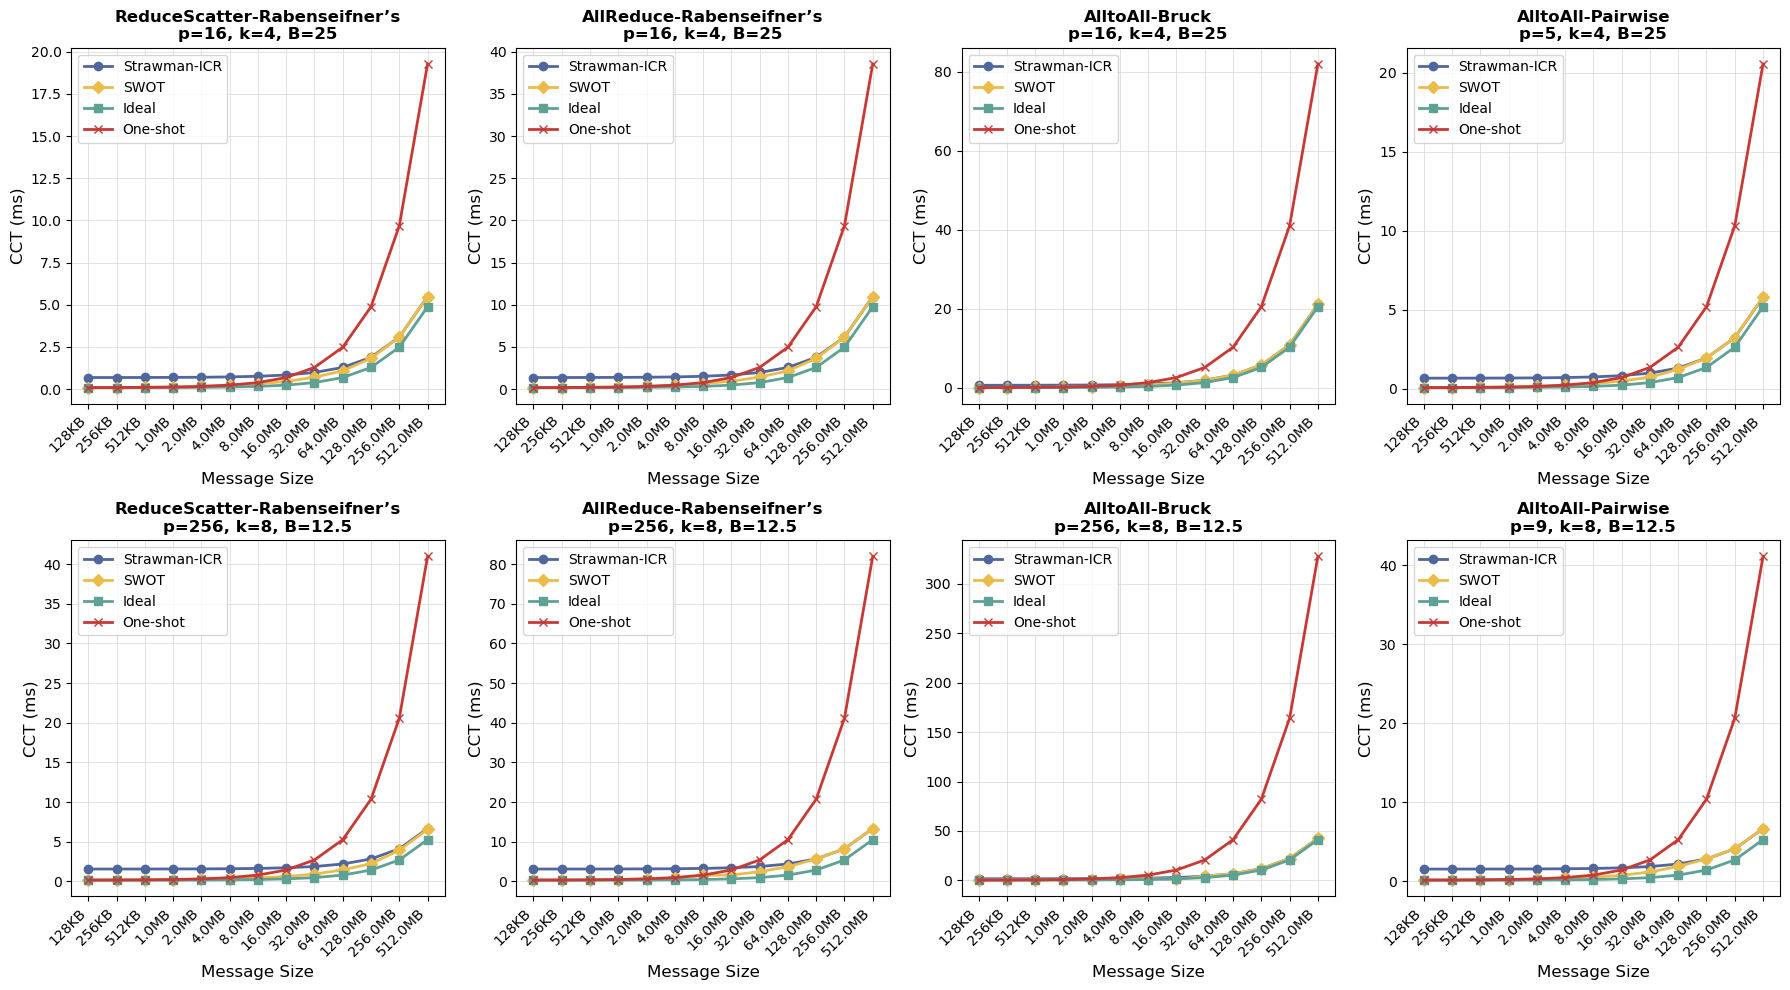

In [3]:
results_path = Path("../logs/results-exp1.1.csv")
df = pd.read_csv(results_path)

df = df[df["status"] == "success"].copy()
df["message_mib"] = df["message_mib"].astype(float)
df.sort_values("message_mib", inplace=True)

# Filter data range
min_size = 0.05 # Down to 0.125
max_size = 512 # Up to 512

mask = np.ones(len(df), dtype=bool)
if min_size is not None:
    mask &= df["message_mib"] >= min_size
if max_size is not None:
    mask &= df["message_mib"] <= max_size

df = df[mask].copy()

# 0. 预处理（极少量因为求解时间不足等而导致结果没有收敛，应退化为Strawman或one-shot策略）
# Preprocess: when optimized_cct > baseline_cct, use baseline_cct
df.loc[df["optimized_cct"] > df["baseline_cct"], "optimized_cct"] = df.loc[df["optimized_cct"] > df["baseline_cct"], "baseline_cct"]
# Preprocess: when optimized_cct > oneshot_cct, use oneshot_cct
df.loc[df["optimized_cct"] > df["oneshot_cct"], "optimized_cct"] = df.loc[df["optimized_cct"] > df["oneshot_cct"], "oneshot_cct"]


# 1. 定义配置
configs = [
    # row 0
    {"alg": "rs_having-doubling", "p": 16, "k": 4, "B": 25}, # NOTE: empty
    {"alg": "ar_having-doubling", "p": 16, "k": 4, "B": 25},
    {"alg": "a2a_bruck", "p": 16, "k": 4, "B": 25},
    {"alg": "a2a_pairwise", "p": 5, "k": 4, "B": 25},
    # row 1
    {"alg": "rs_having-doubling", "p": 256, "k": 8, "B": 12.5},
    {"alg": "ar_having-doubling", "p": 256, "k": 8, "B": 12.5},
    {"alg": "a2a_bruck", "p": 256, "k": 8, "B": 12.5},
    {"alg": "a2a_pairwise", "p": 9, "k": 8, "B": 12.5},
]
alg_labels = {
    'rs_having-doubling': 'ReduceScatter-Rabenseifner’s',
    'ar_having-doubling': 'AllReduce-Rabenseifner’s',
    'a2a_bruck': 'AlltoAll-Bruck',
    'a2a_pairwise': 'AlltoAll-Pairwise'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for idx, conf in enumerate(configs):
    row, col = divmod(idx, 4)
    ax = axes[row, col]
    subdf = df[(df["algorithm"] == conf["alg"]) & 
               (df["p"] == conf["p"]) & 
               (df["k"] == conf["k"]) & 
               (np.isclose(df["B"], conf["B"]))].copy()
    if subdf.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{alg_labels[conf["alg"]]}\np={conf["p"]}, k={conf["k"]}, B={conf["B"]}')
        continue

    # 横坐标：Message size，单位自动用KB/MB
    msg_kb = subdf["message_mib"] * 1024
    labels = []
    for size in msg_kb:
        if size < 1024:
            labels.append(f'{size:.0f}KB')
        else:
            labels.append(f'{size/1024:.1f}MB')

    # 纵坐标：CCT
    for label, column, style, color in [
        ("Strawman-ICR", "baseline_cct", "-o", "#4f669f"),
        ("SWOT", "optimized_cct", "-D", "#ecbc4a"),
        ("Ideal", "ideal_cct", "-s", "#5ea195"),
        ("One-shot", "oneshot_cct", "-x", "#c73934"),
    ]:
        if column in subdf.columns:
            y_data = subdf[column].replace({0: np.nan})
            ax.plot(range(len(subdf)), y_data, style, color=color, 
                   label=label, linewidth=2, markersize=6)

    ax.set_xticks(range(len(subdf)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    ax.set_xlabel('Message Size', fontsize=12)
    ax.set_ylabel('CCT (ms)', fontsize=12)
    ax.grid(axis='both', which='major', color='#d5d6d5', linewidth=0.5)

    # Title
    ax.set_title(f'{alg_labels[conf["alg"]]}\np={conf["p"]}, k={conf["k"]}, B={conf["B"]}', fontsize=12, fontweight='bold')

    # 只在第一个子图加图例
    # if idx == 0:
    ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('figures/cct-msgsize_2x4_comparison.pdf', bbox_inches='tight')
plt.show()

从结果中统计 SWOT 相对 Strawman-ICR 的提升百分比，并生成论文中的描述句子

In [4]:
alg_order = ["rs_having-doubling", "ar_having-doubling", "a2a_pairwise", "a2a_bruck"]

# 1. 计算相对于 Strawman 的改进范围
impr_vs_strawman = (
    df[df["algorithm"].isin(alg_order)]
    .groupby("algorithm")["improvement_over_baseline_pct"]
    .agg(["min", "max"])
)

# 2. 计算相对于 One-shot 的改进
# 公式: (oneshot_cct - optimized_cct) / oneshot_cct * 100
df_valid = df[
    df["algorithm"].isin(alg_order) & 
    (df["oneshot_cct"] > 0) & 
    (df["oneshot_cct"].notna())
].copy()

df_valid["impr_vs_oneshot"] = (
    (df_valid["oneshot_cct"] - df_valid["optimized_cct"]) / df_valid["oneshot_cct"] * 100
)

impr_vs_oneshot = (
    df_valid.groupby("algorithm")["impr_vs_oneshot"]
    .agg(["min", "max"])
)

# 3. 构造范围字符串
# 相对于 One-shot
ranges_oneshot_tex = [
    f"{impr_vs_oneshot.loc[alg, 'min']:.1f}\\%\\textendash{impr_vs_oneshot.loc[alg, 'max']:.1f}\\%"
    for alg in alg_order
]

# 相对于 Strawman (up to = max)
up_to_strawman_tex = [
    f"{impr_vs_strawman.loc[alg, 'max']:.1f}\\%"
    for alg in alg_order
]

# 4. 生成论文描述句子
sentence = (
    "Compared to one-shot, SWOT reduces CCT by "
    f"{ranges_oneshot_tex[0]}, {ranges_oneshot_tex[1]}, {ranges_oneshot_tex[2]}, and {ranges_oneshot_tex[3]} "
    "for Rabenseifner's ReduceScatter, AllReduce, Pairwise All-to-All, and Bruck's All-to-All, respectively; "
    "compared to \\strawman, SWOT reduces the CCT by up to "
    f"{up_to_strawman_tex[0]}, {up_to_strawman_tex[1]}, {up_to_strawman_tex[2]}, and {up_to_strawman_tex[3]} "
    "for the four algorithms respectively."
)

print("=" * 80)
print("Statistics Summary:")
print("=" * 80)
print("\nImprovement vs One-shot:")
print(impr_vs_oneshot)
print("\nImprovement vs Strawman:")
print(impr_vs_strawman)
print("\n" + "=" * 80)
print("Generated Sentence:")
print("=" * 80)
print(sentence)

Statistics Summary:

Improvement vs One-shot:
                    min        max
algorithm                         
a2a_bruck           0.0  89.711537
a2a_pairwise        0.0  83.754864
ar_having-doubling  0.0  83.740234
rs_having-doubling  0.0  83.958333

Improvement vs Strawman:
                             min        max
algorithm                                  
a2a_bruck          -1.839036e+01  85.401460
a2a_pairwise       -1.534360e+01  89.111289
ar_having-doubling -1.928262e+01  87.099438
rs_having-doubling  1.441848e-14  89.113757

Generated Sentence:
Compared to one-shot, SWOT reduces CCT by 0.0\%\textendash84.0\%, 0.0\%\textendash83.7\%, 0.0\%\textendash83.8\%, and 0.0\%\textendash89.7\% for Rabenseifner's ReduceScatter, AllReduce, Pairwise All-to-All, and Bruck's All-to-All, respectively; compared to \strawman, SWOT reduces the CCT by up to 89.1\%, 87.1\%, 89.1\%, and 85.4\% for the four algorithms respectively.


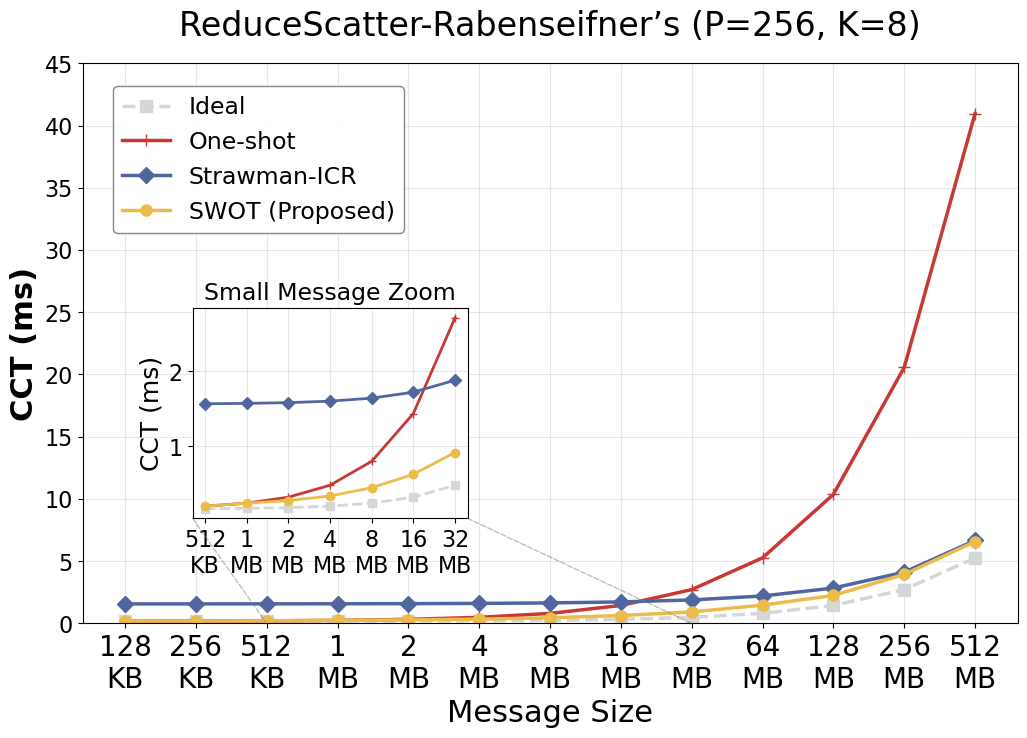

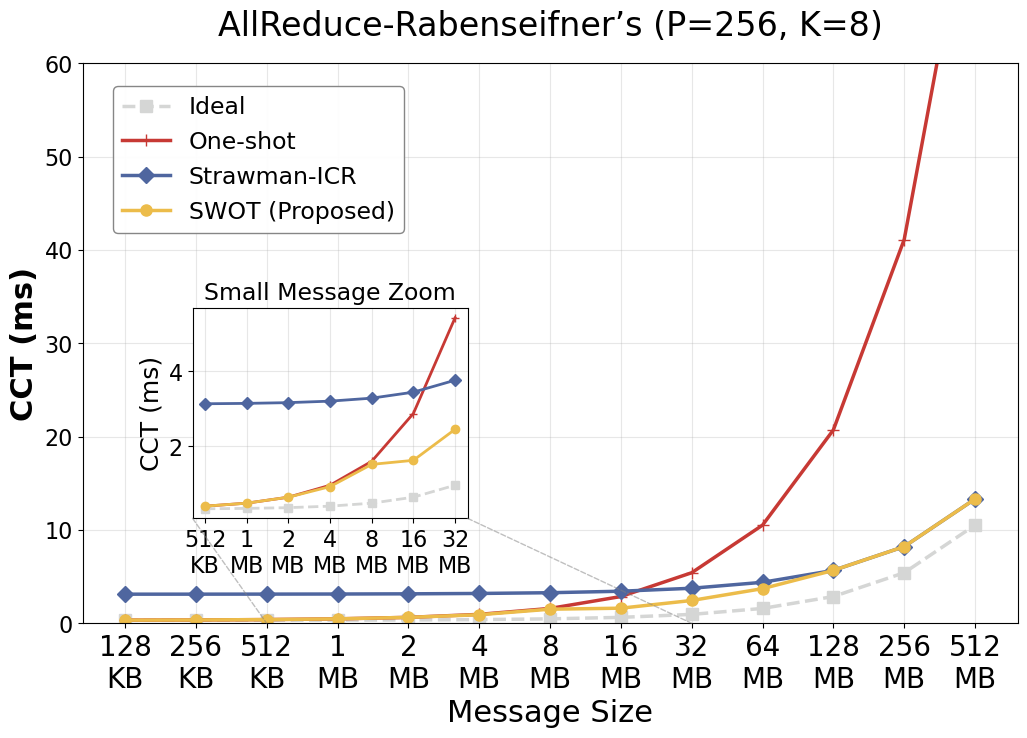

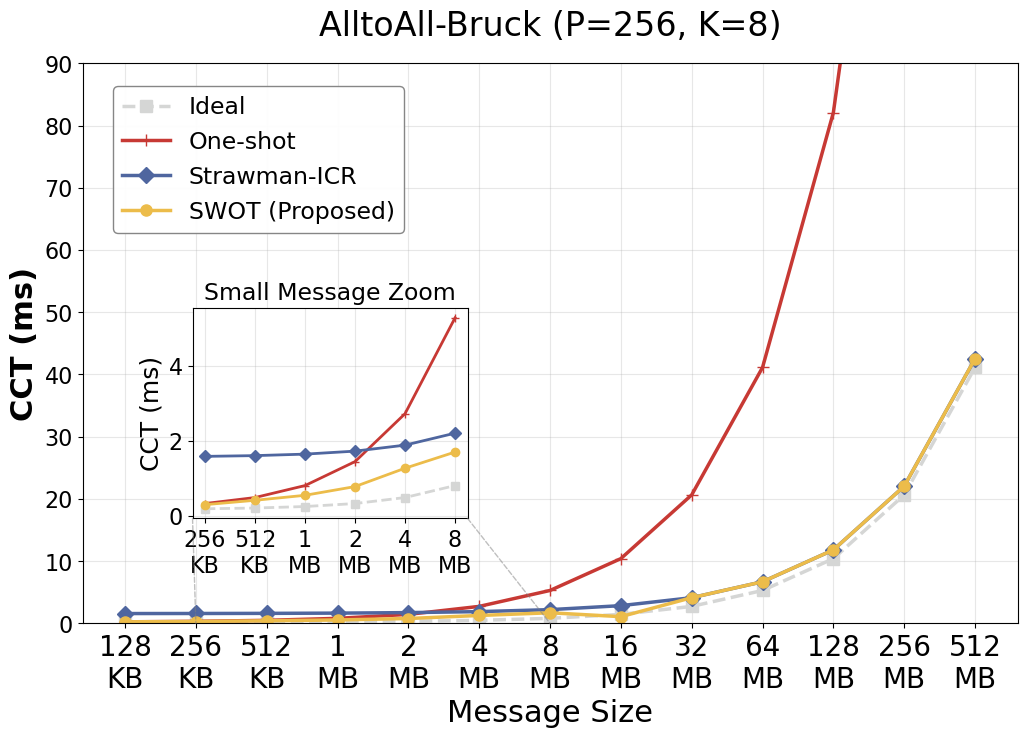

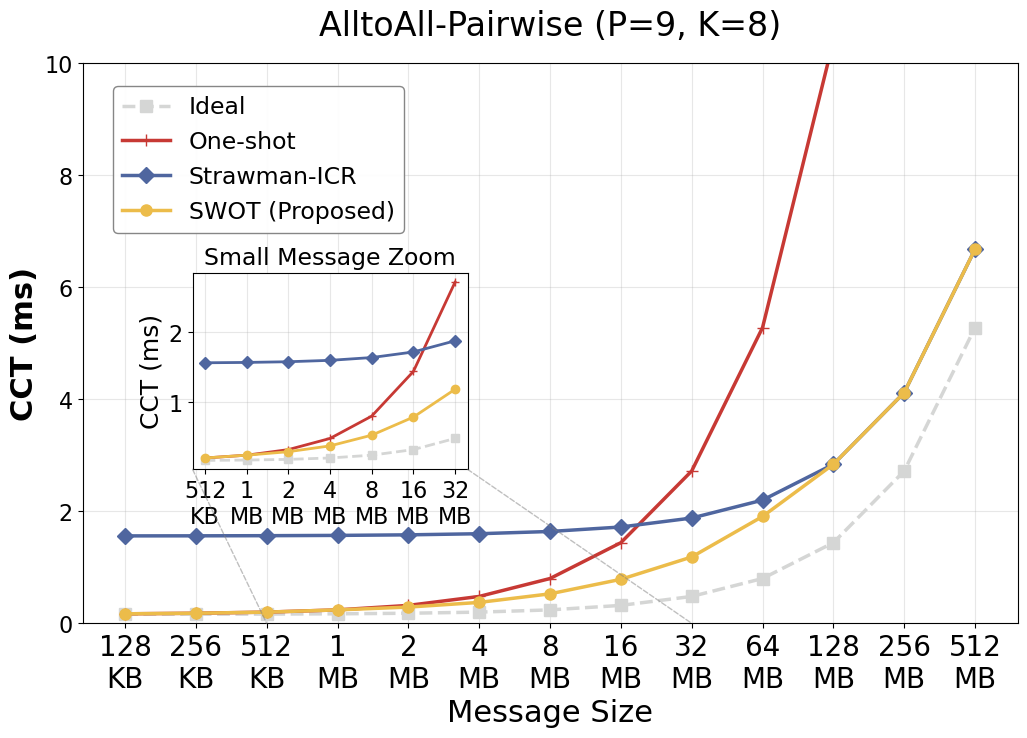

In [15]:
from matplotlib.patches import ConnectionPatch

# ==========================================
# 样式保持不变
# ==========================================
STYLE = {
    'SWOT':       {'c': "#ecbc4a", 'm': 'o', 'l': 'SWOT (Proposed)'},     # 蓝色
    'Strawman':   {'c': "#4f669f", 'm': 'D', 'l': 'Strawman-ICR'},        # 红色
    'One-shot':   {'c': "#c73934", 'm': '+', 'l': 'One-shot'},            # 橙色
    'Ideal':      {'c': '#d5d6d5', 'm': 's', 'l': 'Ideal'},               # 绿色
    'font_size': 16
}

def format_size_label(mib_val):
    kb_val = mib_val * 1024
    if kb_val < 1024:
        return f"{kb_val:.0f}\nKB"
    else:
        return f"{kb_val/1024:.0f}\nMB"

def draw_paper_style_plot_v3(df, target_config, zoom_idx_range=(0, 6), 
                             manual_ylim=None, use_log_y=False, 
                             inset_position=[0.22, 0.25, 0.25, 0.25],
                             save_fig_filename=None):
    """
    参数增加了:
    manual_ylim: (可选) 手动指定 Y 轴最大值，例如 500
    use_log_y: (可选) 是否使用对数 Y 轴
    inset_position: (可选) inset 图位置和大小 [left, bottom, width, height]
    save_fig_filename: (可选) 保存图片的文件名
    """
    
    # --- 1. 数据准备 ---
    subdf = df[(df["algorithm"] == target_config["alg"]) & 
               (df["p"] == target_config["p"]) & 
               (df["k"] == target_config["k"]) & 
               (np.isclose(df["B"], target_config["B"]))].copy()
    
    if subdf.empty:
        print("Error: No data found.")
        return

    subdf.sort_values("message_mib", inplace=True)
    subdf.reset_index(drop=True, inplace=True)

    y_straw = subdf["baseline_cct"].replace({0: np.nan}).values
    y_swot  = subdf["optimized_cct"].replace({0: np.nan}).values
    y_ideal = subdf["ideal_cct"].replace({0: np.nan}).values
    y_oneshot = subdf["oneshot_cct"].replace({0: np.nan}).values

    x_indices = np.arange(len(subdf))
    x_labels = [format_size_label(s) for s in subdf["message_mib"]]

    # --- 2. 创建画布 ---
    fig = plt.figure(figsize=(11, 7), dpi=100)
    plt.rcParams.update({'font.size': STYLE['font_size']})
    ax_main = fig.add_axes([0.1, 0.1, 0.85, 0.8])

    # --- 3. 绘制主图 ---
    lw, ms = 2.5, 8
    
    ax_main.plot(x_indices, y_ideal, c=STYLE['Ideal']['c'], marker=STYLE['Ideal']['m'], 
                 lw=lw, ms=ms, label=STYLE['Ideal']['l'], ls='--')
    if not np.all(np.isnan(y_oneshot)):
        ax_main.plot(x_indices, y_oneshot, c=STYLE['One-shot']['c'], marker=STYLE['One-shot']['m'], 
                     lw=lw, ms=ms, label=STYLE['One-shot']['l'])
    ax_main.plot(x_indices, y_straw, c=STYLE['Strawman']['c'], marker=STYLE['Strawman']['m'], 
                 lw=lw, ms=ms, label=STYLE['Strawman']['l'])
    ax_main.plot(x_indices, y_swot, c=STYLE['SWOT']['c'], marker=STYLE['SWOT']['m'], 
                 lw=lw, ms=ms, label=STYLE['SWOT']['l'])

    # 设置 X 轴
    ax_main.set_xticks(x_indices)
    ax_main.set_xticklabels(x_labels, fontsize=20)
    ax_main.set_xlabel('Message Size', fontsize=22)
    
    # 设置 Y 轴 (关键修改点)
    ax_main.set_ylabel('CCT (ms)', fontsize=22, fontweight='bold')
    
    if use_log_y:
        ax_main.set_yscale('log')
    else:
        # 如果没有手动指定，自动计算所有数据的最大值
        if manual_ylim is None:
            # 收集所有非 NaN 的数据来计算最大值
            all_data = [y_straw, y_swot, y_ideal]
            if not np.all(np.isnan(y_oneshot)):
                all_data.append(y_oneshot)
            
            # 计算最大值并增加 20% 的顶部留白
            global_max = np.nanmax([np.nanmax(d) for d in all_data])
            ax_main.set_ylim(0, global_max * 1.2)
        else:
            # 使用用户手动指定的值
            ax_main.set_ylim(0, manual_ylim)

    # 标题与网格
    title_str = f"{alg_labels.get(target_config['alg'], target_config['alg'])} (P={target_config['p']}, K={target_config['k']})"
    ax_main.set_title(title_str, fontsize=24, pad=20)
    ax_main.grid(True, linestyle='-', alpha=0.3)

    # --- 4. 图例 ---
    ax_main.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), fontsize=17, 
                   frameon=True, edgecolor='gray', facecolor='white', framealpha=0.95)

    # --- 5. 绘制 Inset (Zoom) ---
    zoom_start, zoom_end = zoom_idx_range
    x_zoom = x_indices[zoom_start:zoom_end]
    
    ax_ins2 = fig.add_axes(inset_position) 

    ax_ins2.plot(x_zoom, y_ideal[zoom_start:zoom_end], c=STYLE['Ideal']['c'], marker=STYLE['Ideal']['m'], lw=2, ls='--')
    if not np.all(np.isnan(y_oneshot)):
        ax_ins2.plot(x_zoom, y_oneshot[zoom_start:zoom_end], c=STYLE['One-shot']['c'], marker=STYLE['One-shot']['m'], lw=2)
    ax_ins2.plot(x_zoom, y_straw[zoom_start:zoom_end], c=STYLE['Strawman']['c'], marker=STYLE['Strawman']['m'], lw=2)
    ax_ins2.plot(x_zoom, y_swot[zoom_start:zoom_end], c=STYLE['SWOT']['c'], marker=STYLE['SWOT']['m'], lw=2)

    ax_ins2.set_xticks(x_zoom)
    # 保持与主图一致：数值和单位换行，如 "32\nMB"
    ax_ins2.set_xticklabels(x_labels[zoom_start:zoom_end], fontsize=16)
    ax_ins2.set_ylabel('CCT (ms)', fontsize=18)
    ax_ins2.grid(True, alpha=0.3)
    ax_ins2.set_title("Small Message Zoom", fontsize=17)
    ax_ins2.set_facecolor('white')

    # --- 6. 连接线 ---
    # 如果是对数坐标，连接线的底部不能是 0，需要设为 None 或者一个很小的值，这里简单处理
    y_conn_bottom = 0 
    
    con1 = ConnectionPatch(xyA=(0, 0), xyB=(zoom_start, y_conn_bottom), 
                           coordsA="axes fraction", coordsB="data",
                           axesA=ax_ins2, axesB=ax_main, color="gray", linestyle="--", alpha=0.5)
    con2 = ConnectionPatch(xyA=(1, 0), xyB=(zoom_end-1, y_conn_bottom), 
                           coordsA="axes fraction", coordsB="data",
                           axesA=ax_ins2, axesB=ax_main, color="gray", linestyle="--", alpha=0.5)
    fig.add_artist(con1)
    fig.add_artist(con2)

    # --- 7. 保存图片 ---
    if save_fig_filename:
        plt.savefig(save_fig_filename, bbox_inches='tight')
    
    plt.show()

# ==========================================
# 调用示例
# ==========================================

target_conf = configs[0]

# 情况 A：自动计算 (现在会包含所有点，并增加 20% 高度)
# draw_paper_style_plot_v3(df, target_conf, zoom_idx_range=(0, 6))

# 情况 B：手动指定高度 (解决你的问题)
# 如果看图觉得最高点大概是 180，可以设为 200 或 250
# draw_paper_style_plot_v3(df, target_conf, zoom_idx_range=(2, 9), manual_ylim=30, 
#                          inset_position=[0.22, 0.25, 0.25, 0.25],
#                          save_fig_filename='output_figure.png')

draw_paper_style_plot_v3(df, configs[4], zoom_idx_range=(2, 9), manual_ylim=45, 
                         inset_position=[0.2, 0.25, 0.25, 0.3],
                         save_fig_filename='figures/exp1.1-rs-hd.pdf')

draw_paper_style_plot_v3(df, configs[5], zoom_idx_range=(2, 9), manual_ylim=60, 
                         inset_position=[0.20, 0.25, 0.25, 0.3],
                         save_fig_filename='figures/exp1.1-ar-hd.pdf')

draw_paper_style_plot_v3(df, configs[6], zoom_idx_range=(1, 7), manual_ylim=90, 
                         inset_position=[0.2, 0.25, 0.25, 0.3],
                         save_fig_filename='figures/exp1.1-a2a-bruck.pdf')

draw_paper_style_plot_v3(df, configs[7], zoom_idx_range=(2, 9), manual_ylim=10, 
                         inset_position=[0.2, 0.32, 0.25, 0.28],
                         save_fig_filename='figures/exp1.1-a2a-pair.pdf')

# 情况 C：如果数值差异太大 (比如有 10000ms 的点)
# draw_paper_style_plot_v3(df, target_conf, zoom_idx_range=(0, 6), use_log_y=True)

---

## 实验 1.2：不同通信算法，不同方案对**可扩展性**的影响

|`algorithms`|`k, B`|`m`|`p`|
|-|-|-|-|
|hd, bruck|4, 25|32|[4, k^2] $\cup$ [k^2, 1024]|
|pairwise|4, 25|32|[4, k+1] $\cup$ [k+1, 14]|


- `exp1.2-hd+bruck.toml`
- `exp1.2-pair.toml`


### 1.2.1 AllReduce

In [16]:
# Load and filter data
results_path = Path("../logs/matrix_results-exp1.2-hd+bruck.csv")
df = pd.read_csv(results_path)

target_config = {
    "status": "success",    
    "alg": "ar_having-doubling",
    "k": 4,
    "B": 25,
}

filtered_ar_hd_df = df[(df["algorithm"] == target_config["alg"]) & 
                 (df["k"] == target_config["k"]) & 
                 (df["status"] == target_config["status"]) & 
                 (np.isclose(df["B"], target_config["B"]))].copy()

Improvement from multi to ours: 23.0% - 50.0%


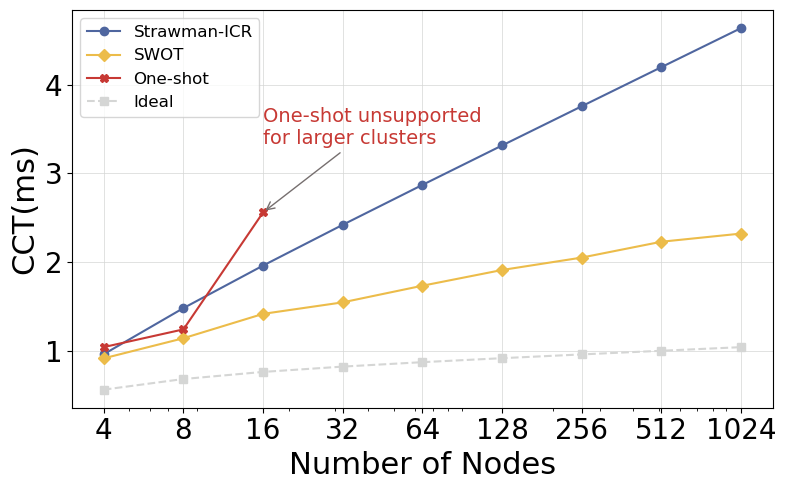

In [24]:
# Sort by number of nodes to ensure proper order
filtered_ar_hd_df = filtered_ar_hd_df.sort_values('p')

# Extract data for plotting
num_gpus = filtered_ar_hd_df['p'].tolist()
gpu_labels = [str(x) for x in num_gpus]

CCT_multi   = filtered_ar_hd_df['baseline_cct'].tolist()
CCT_ours    = filtered_ar_hd_df['optimized_cct'].tolist()
CCT_one     = filtered_ar_hd_df['oneshot_cct'].tolist()
CCT_ideal   = filtered_ar_hd_df['ideal_cct'].tolist()

# Calculate improvement ratios (excluding first data point)
multi_to_ours = [(1 - ours/multi) * 100 for multi, ours in zip(CCT_multi[1:], CCT_ours[1:]) if multi > 0]
print(f"Improvement from multi to ours: {min(multi_to_ours):.1f}% - {max(multi_to_ours):.1f}%")

# Create mask for valid One-shot data (non-NaN)
mask = np.array([x is not None and not pd.isna(x) for x in CCT_one])

# Check where One-shot data ends to place annotation
oneshot_limit_idx = np.where(mask)[0][-1] if np.any(mask) else 0
oneshot_limit_p = num_gpus[oneshot_limit_idx]

# Set figure size and style parameters
plt.figure(figsize=(8, 5))
plt.rc('font', size=10)
plt.rc('axes', labelsize=22)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('legend', fontsize=12)

# Plot data
plt.plot(num_gpus, CCT_multi, linestyle='solid', c='#4f669f', marker='o', label='Strawman-ICR')
plt.plot(num_gpus, CCT_ours, linestyle='solid', c='#ecbc4a', marker='D', label='SWOT')
plt.plot(np.array(num_gpus)[mask], np.array(CCT_one)[mask],
         linestyle='solid', c='#c73934', marker='X', label='One-shot')
plt.plot(num_gpus, CCT_ideal, linestyle='dashed', c='#d5d6d5', marker='s', label='Ideal')

# Add annotation for One-shot limitation
if np.any(mask):
    plt.annotate('One-shot unsupported\nfor larger clusters', 
                 xy=(oneshot_limit_p, CCT_one[oneshot_limit_idx]), 
                 xytext=(oneshot_limit_p * 1, max(CCT_one[oneshot_limit_idx], CCT_multi[oneshot_limit_idx])*1.3),
                 arrowprops=dict(arrowstyle="->", color="#766f6f", linewidth=1),
                 color='#c73934', fontsize=14)

# Formatting
plt.xlabel('Number of Nodes')
plt.ylabel('CCT(ms)')
plt.xscale('log')
plt.xticks(num_gpus, gpu_labels)
plt.grid(axis='both', which='major', color='#d5d6d5', linewidth=0.5)

plt.tight_layout()
plt.legend()
plt.savefig('figures/exp1.2-ar_hd.pdf', bbox_inches='tight')
plt.show()

### 1.2.2 All-to-all Bruck

In [69]:
# Load and filter data
results_path = Path("../logs/matrix_results-exp1.2-hd+bruck.csv")
df = pd.read_csv(results_path)

target_config = {
    "status": "success",    
    "alg": "a2a_bruck",
    "k": 4,
    "B": 25,
}

filtered_a2a_bruck_df = df[(df["algorithm"] == target_config["alg"]) & 
                 (df["k"] == target_config["k"]) & 
                 (df["status"] == target_config["status"]) & 
                 (np.isclose(df["B"], target_config["B"]))].copy()

Improvement from multi to ours: 26.0% - 54.2%


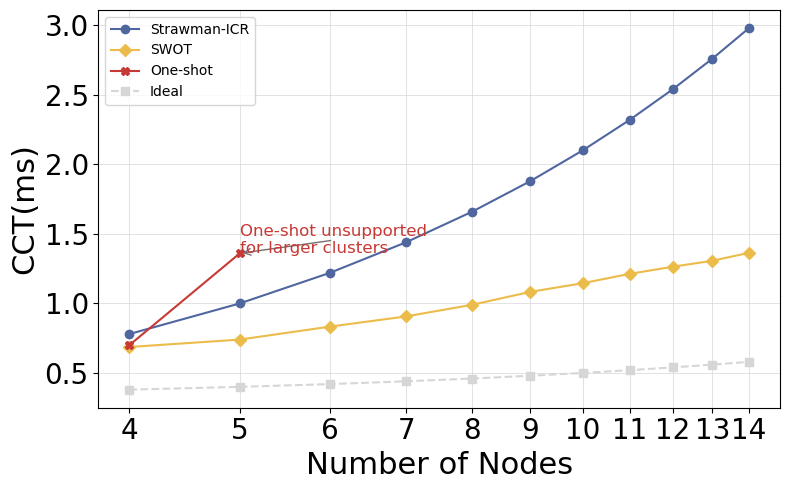

In [77]:
# Sort by number of nodes to ensure proper order
filtered_a2a_bruck_df = filtered_a2a_bruck_df.sort_values('p')

# Extract data for plotting
num_gpus = filtered_a2a_bruck_df['p'].tolist()
gpu_labels = [str(x) for x in num_gpus]

CCT_multi   = filtered_a2a_bruck_df['baseline_cct'].tolist()
CCT_ours    = filtered_a2a_bruck_df['optimized_cct'].tolist()
CCT_one     = filtered_a2a_bruck_df['oneshot_cct'].tolist()
CCT_ideal   = filtered_a2a_bruck_df['ideal_cct'].tolist()

# Calculate improvement ratios (excluding first data point)
multi_to_ours = [(1 - ours/multi) * 100 for multi, ours in zip(CCT_multi[1:], CCT_ours[1:]) if multi > 0]
print(f"Improvement from multi to ours: {min(multi_to_ours):.1f}% - {max(multi_to_ours):.1f}%")

# Create mask for valid One-shot data (non-NaN)
mask = np.array([x is not None and not pd.isna(x) for x in CCT_one])

# Check where One-shot data ends to place annotation
oneshot_limit_idx = np.where(mask)[0][-1] if np.any(mask) else 0
oneshot_limit_p = num_gpus[oneshot_limit_idx]

# Set figure size and style parameters
plt.figure(figsize=(8, 5))
plt.rc('font', size=10)
plt.rc('axes', labelsize=22)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('legend', fontsize=10)

# Plot data
plt.plot(num_gpus, CCT_multi, linestyle='solid', c='#4f669f', marker='o', label='Strawman-ICR')
plt.plot(num_gpus, CCT_ours, linestyle='solid', c='#ecbc4a', marker='D', label='SWOT')
plt.plot(np.array(num_gpus)[mask], np.array(CCT_one)[mask],
         linestyle='solid', c='#c73934', marker='X', label='One-shot')
plt.plot(num_gpus, CCT_ideal, linestyle='dashed', c='#d5d6d5', marker='s', label='Ideal')

# Add annotation for One-shot limitation
if np.any(mask):
    plt.annotate('One-shot unsupported\nfor larger clusters', 
                 xy=(oneshot_limit_p, CCT_one[oneshot_limit_idx]), 
                 xytext=(oneshot_limit_p * 1, max(CCT_one[oneshot_limit_idx], CCT_multi[oneshot_limit_idx])*1),
                 arrowprops=dict(arrowstyle="->", color="#766f6f", linewidth=1),
                 color='#c73934', fontsize=12)

# Formatting
plt.xlabel('Number of Nodes')
plt.ylabel('CCT(ms)')
plt.xscale('log')
plt.xticks(num_gpus, gpu_labels)
plt.grid(axis='both', which='major', color='#d5d6d5', linewidth=0.5)

plt.tight_layout()
plt.legend()
plt.savefig('figures/exp1.2-a2a_bruck.pdf', bbox_inches='tight')
plt.show()

### 1.2.3 All-to-all Pairwise

In [26]:
# Load and filter data
results_path = Path("../logs/matrix_results-exp1.2-pair.csv")
df = pd.read_csv(results_path)

target_config = {
    "status": "success",    
    "alg": "a2a_pairwise",
    "k": 4,
    "B": 25,
}

filtered_a2a_pair_df = df[(df["algorithm"] == target_config["alg"]) & 
                 (df["k"] == target_config["k"]) & 
                 (df["status"] == target_config["status"]) & 
                 (np.isclose(df["B"], target_config["B"]))].copy()

Improvement from multi to ours: 26.0% - 54.2%


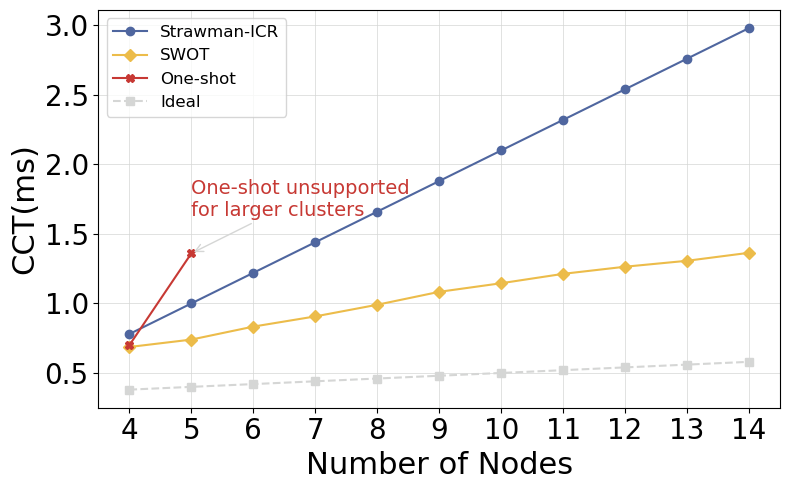

In [27]:
# Sort by number of nodes to ensure proper order
filtered_a2a_pair_df = filtered_a2a_pair_df.sort_values('p')

# Extract data for plotting
num_gpus = filtered_a2a_pair_df['p'].tolist()
gpu_labels = [str(x) for x in num_gpus]

CCT_multi   = filtered_a2a_pair_df['baseline_cct'].tolist()
CCT_ours    = filtered_a2a_pair_df['optimized_cct'].tolist()
CCT_one     = filtered_a2a_pair_df['oneshot_cct'].tolist()
CCT_ideal   = filtered_a2a_pair_df['ideal_cct'].tolist()

# Calculate improvement ratios (excluding first data point)
multi_to_ours = [(1 - ours/multi) * 100 for multi, ours in zip(CCT_multi[1:], CCT_ours[1:]) if multi > 0]
print(f"Improvement from multi to ours: {min(multi_to_ours):.1f}% - {max(multi_to_ours):.1f}%")

# Create mask for valid One-shot data (non-NaN)
mask = np.array([x is not None and not pd.isna(x) for x in CCT_one])

# Check where One-shot data ends to place annotation
oneshot_limit_idx = np.where(mask)[0][-1] if np.any(mask) else 0
oneshot_limit_p = num_gpus[oneshot_limit_idx]

# Set figure size and style parameters
plt.figure(figsize=(8, 5))
plt.rc('font', size=10)
plt.rc('axes', labelsize=22)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('legend', fontsize=12)

# Plot data
plt.plot(num_gpus, CCT_multi, linestyle='solid', c='#4f669f', marker='o', label='Strawman-ICR')
plt.plot(num_gpus, CCT_ours, linestyle='solid', c='#ecbc4a', marker='D', label='SWOT')
plt.plot(np.array(num_gpus)[mask], np.array(CCT_one)[mask],
         linestyle='solid', c='#c73934', marker='X', label='One-shot')
plt.plot(num_gpus, CCT_ideal, linestyle='dashed', c='#d5d6d5', marker='s', label='Ideal')

# Add annotation for One-shot limitation
if np.any(mask):
    plt.annotate('One-shot unsupported\nfor larger clusters', 
                 xy=(oneshot_limit_p, CCT_one[oneshot_limit_idx]), 
                 xytext=(oneshot_limit_p * 1, max(CCT_one[oneshot_limit_idx], CCT_multi[oneshot_limit_idx])*1.2),
                 arrowprops=dict(arrowstyle="->", color="#d5d6d5", linewidth=1),
                 color='#c73934', fontsize=14)

# Formatting
plt.xlabel('Number of Nodes')
plt.ylabel('CCT(ms)')
# plt.xscale('log')
plt.xticks(num_gpus, gpu_labels)
plt.grid(axis='both', which='major', color='#d5d6d5', linewidth=0.5)

plt.tight_layout()
plt.legend()
plt.savefig('figures/exp1.2-a2a_pair.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# 根据 filtered_ar_hd_df 和 filtered_a2a_pair_df 重新计算文中描述所需的提升百分比
def get_improvement_pct(df, p_value, col="improvement_over_baseline_pct"):
    row = df[df["p"] == p_value]
    if row.empty:
        raise ValueError(f"No data found for p={p_value}")
    return float(row[col].iloc[0])

# Rabenseifner's AllReduce: 64 节点和 512 节点
ar_impr_64 = get_improvement_pct(filtered_ar_hd_df, 64)
ar_impr_512 = get_improvement_pct(filtered_ar_hd_df, 512)

# Pairwise All-to-All: 5 节点和 10 节点
pair_impr_5 = get_improvement_pct(filtered_a2a_pair_df, 5)
pair_impr_10 = get_improvement_pct(filtered_a2a_pair_df, 10)

print("Rabenseifner AllReduce improvements:")
print(f"  64 nodes : {ar_impr_64:.2f}%")
print(f" 512 nodes : {ar_impr_512:.2f}%\n")

print("Pairwise All-to-All improvements:")
print(f"   5 nodes : {pair_impr_5:.2f}%")
print(f"  10 nodes : {pair_impr_10:.2f}%\n")

# 生成更新后的论文句子（LaTeX 用）
sentence_scalability = (
    "\\ours's performance over \\strawman improves with cluster size: "
    f"for {{Rabenseifner's}} AllReduce, CCT reduction grows from {ar_impr_64:.1f}\\% at 64 nodes "
    f"to {ar_impr_512:.1f}\\% at 512 nodes; "
    f"for {{Pairwise}} All-to-All, improvement rises from {pair_impr_5:.1f}\\% at 5 nodes "
    f"to {pair_impr_10:.1f}\\% at 10 nodes. "
    "Large-scale clusters will see greater benefits from \\ours, highlighting its scalability for "
    "{complex CC algorithms in} larger systems."
)

print("Updated paper sentence:\n")
print(sentence_scalability)

Rabenseifner AllReduce improvements:
  64 nodes : 39.63%
 512 nodes : 46.92%

Pairwise All-to-All improvements:
   5 nodes : 26.00%
  10 nodes : 45.47%

Updated paper sentence:

\ours(SWOT). \ours's performance over \strawman improves with cluster size: for {Rabenseifner's} AllReduce, CCT reduction grows from 39.6\% at 64 nodes to 46.9\% at 512 nodes; for {Pairwise} All-to-All, improvement rises from 26.0\% at 5 nodes to 45.5\% at 10 nodes. Large-scale clusters will see greater benefits from \ours, highlighting its scalability for {complex CC algorithms in} larger systems.


---

## 实验1.3：不同__通信原语__，不同方案对的性能CCT的影响

### AllReduce Apples-to-Apples Comparison

##### AR数据注释
:warning: 数据组成：
1. exp1.3-ar_rb.toml 计算
1. cost model计算所得（计算 Ring, DBT 等不需要 reconfig 的 Algo.）
1. exp1.1-hd+bruck-2.toml(hd部分) 复用

---

1. exp1.3-ar_rb.toml 计算（略）

2. cost model计算所得（计算 Ring, DBT 等不需要 reconfig 的 Algo.）

In [ ]:
# NOTE: AR Ring 和 AR DBT 的数据
import csv, math, datetime, hashlib, os, json

# ---------------- 参数区 ----------------
LOG_CSV = "../logs/matrix_results-exp1.3-ar.csv"

k = 8
B = 12.5
T_reconf = 0.2
T_lat = 0.02
p = 256
message_sizes_mib = [0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0, 512.0]

# 确保目录存在
os.makedirs(os.path.dirname(LOG_CSV), exist_ok=True)
# ---------------- /参数区 ----------------

def make_run_id(alg: str, m: float) -> str:
    """生成与已有日志风格一致的 run_id"""
    m_str = str(m).replace(".", "p")
    ts = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    return f"{ts}_exp1.3-ar_{alg}__B{B}p_T_lat{T_lat}p_T_reconf{T_reconf}p_k{k}_p{p}_m{m_str}"

def compute_hash(row: dict) -> str:
    """对整行内容（不含 hash 字段本身）算 sha1，保持与旧日志一致"""
    # 按列顺序拼接字符串
    keys = ["timestamp", "matrix_id", "run_id", "config_path", "algorithm",
            "message_mib", "solver", "solver_gap", "solver_time_limit",
            "k", "T_reconf", "T_lat", "B", "p", "status", "returncode",
            "duration_seconds", "optimized_cct", "baseline_cct", "oneshot_cct",
            "ideal_cct", "improvement_over_baseline_pct", "metrics_path"]
    payload = "|".join(str(row.get(k, "")) for k in keys)
    return hashlib.sha1(payload.encode()).hexdigest()

def nccl_optimal_k(message_size_mib, p):
    """
    模拟NCCL的chunk size选择策略，返回最优流水线粒度k
    """
    # 转换为字节用于阈值判断
    message_size_bytes = message_size_mib * 1024 * 1024
    
    # NCCL启发式规则：基于消息大小和节点数
    if message_size_bytes < 16 * 1024:  # < 16KB
        base_chunk_size_bytes = 128 * 1024  # 128KB
    elif message_size_bytes < 1 * 1024 * 1024:  # < 1MB
        base_chunk_size_bytes = 256 * 1024  # 256KB
    else:  # >= 1MB
        base_chunk_size_bytes = 512 * 1024  # 512KB
    
    # 根据节点数调整：NCCL通常限制最大并行度
    max_parallelism = min(p, 8)  # NCCL典型限制
    adjusted_chunk_size_bytes = base_chunk_size_bytes * max_parallelism
    
    # 转换为MiB
    adjusted_chunk_size_mib = adjusted_chunk_size_bytes / (1024 * 1024)
    
    # 计算最优k：消息大小 / chunk大小，限制在[1, p]范围内
    chunk_num = max(1, min(p, int(message_size_mib / adjusted_chunk_size_mib)))
    
    # 确保k是2的幂次（NCCL偏好）
    if chunk_num > 1:
        chunk_num = 2 ** int(math.log2(chunk_num))
    
    return chunk_num

def calc_dbt(msg_size_mb, chunk_num):
    # 1. 计算chunk大小
    chunk_size_mib = msg_size_mb / chunk_num
    # 2. 计算步骤数：2*log2(p) + 2*(chunk_num-1)
    steps = 2 * math.ceil(math.log2(p)) + 2 * (chunk_num - 1)
    # 3. 每步通信时间：alpha + beta * (chunk_size / 2)
    time_per_step = T_lat +  (chunk_size_mib / 2) / k / B
    # 4. 总时间 = 重配置时间 + 步骤数 × 每步时间
    total_time = T_reconf + steps * time_per_step
    
    return total_time  # 返回ms

def calc_dbt_time(m_mib, chunk_num):
    """计算给定流水线粒度chunk_num下的DBT时间"""
    n_chunks = chunk_num
    chunk_size = m_mib / n_chunks
    
    # 步骤数: 2*log2(p) + 2*(k-1)
    steps = 2 * math.ceil(math.log2(p)) + 2 * (n_chunks - 1)
    
    # 每步通信时间: alpha + beta * (chunk_size / 2)
    time_per_step = T_lat + (chunk_size / 2) / chunk_num / B
    
    return T_reconf + steps * time_per_step

# 如果文件不存在，先写表头
write_header = not os.path.isfile(LOG_CSV)
with open(LOG_CSV, "a", newline="") as f:
    writer = csv.writer(f)
    if write_header:
        writer.writerow([
            "timestamp", "matrix_id", "run_id", "config_path", "algorithm",
            "message_mib", "solver", "solver_gap", "solver_time_limit",
            "k", "T_reconf", "T_lat", "B", "p", "status", "returncode",
            "duration_seconds", "optimized_cct", "baseline_cct", "oneshot_cct",
            "ideal_cct", "improvement_over_baseline_pct", "metrics_path", "hash"
        ])

    for m in message_sizes_mib:
        # 计算两种算法的 CCT（ms）
        T_ar_ring = T_reconf + (p - 1) * T_lat + m / k / B * (p - 1) / p
        T_ar_dbt = calc_dbt(m, p)        

        chunk_num = nccl_optimal_k(m, p)
        T_ar_dbt_nccl = calc_dbt(m, chunk_num)

        chunk_num_candidates = [2**i for i in range(0, int(math.log2(p))+1)]
        times = [calc_dbt_time(m, chunk_num) for chunk_num in chunk_num_candidates]
        min_idx = np.argmin(times)
        chunk_num_opt = chunk_num_candidates[min_idx]
        t_opt = times[min_idx]
        T_ar_dbt_pipe_opt = t_opt


        ts = datetime.datetime.now().isoformat(timespec="microseconds")
        for alg, cct in [("ar_ring", T_ar_ring), ("ar_dbt", T_ar_dbt), ("ar_dbt_pipe", T_ar_dbt_pipe_opt)]:
            row = {
                "timestamp": ts,
                "matrix_id": f"exp1.3-{alg.replace('_', '-')}",
                "run_id": make_run_id(alg, m),
                "config_path": "nan",
                "algorithm": alg,
                "message_mib": m,
                "solver": "analytical",
                "solver_gap": "nan",
                "solver_time_limit": "nan",
                "k": k,
                "T_reconf": T_reconf,
                "T_lat": T_lat,
                "B": B,
                "p": p,
                "status": "success",
                "returncode": 0,
                "duration_seconds": "nan",
                "optimized_cct": cct,
                "baseline_cct": cct,
                "oneshot_cct": cct,
                "ideal_cct": cct,
                "improvement_over_baseline_pct": 0,
                "metrics_path": "nan"
            }
            row["hash"] = compute_hash(row)
            writer.writerow([row[k] for k in row.keys()])

print(f"Done. 结果已追加到 {LOG_CSV}")

3. exp1.1-hd+bruck-2.toml(hd部分) 复用

In [ ]:
# 从 "../logs/results-exp1.1.csv" 中读取筛选写入到 "../logs/matrix_results-exp1.3-ar.csv"
results_path = Path("../logs/results-exp1.1.csv")
df = pd.read_csv(results_path)

df = df[df['algorithm'].isin(['ar_having-doubling'])].copy()

target_config = {
    "alg": "ar_having-doubling",
    "p": 256,
    "k": 8,
    "B": 12.5
}

subdf = df[(df["algorithm"] == target_config["alg"]) & 
            (df["p"] == target_config["p"]) & 
            (df["k"] == target_config["k"]) & 
            (np.isclose(df["B"], target_config["B"]))].copy()

len(subdf)
# 追加
subdf.to_csv("../logs/matrix_results-exp1.3-ar.csv", mode='a', header=False, index=False)

#### 绘图 （部分函数可被A2A复用）

In [28]:
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import FuncFormatter
import os

1. 样式与映射配置

In [74]:
# 算法名称映射 (缩写)
ALG_SHORT_MAP = {
    'ar_having-doubling': 'HD',
    'ar_recursive-doubling': 'RD',
    'ar_ring': 'R',
    'ar_dbt': 'D',
    'ar_dbt_pipe': 'DP',
    'rs_having-doubling': 'HD', # 如果有 RS 算法
    'rs_ring': 'R'
}

STYLE = {
    'SWOT':       {'c': "#ecbc4a", 'm': 'D', 'l': 'SWOT (Proposed)'}, 
    'Strawman':   {'c': "#4f669f", 'm': 'o', 'l': 'Strawman-ICR'},    
    'One-shot':   {'c': "#c73934", 'm': 'x', 'l': 'One-shot'},        
    'Ideal':      {'c': '#d5d6d5', 'm': 's', 'l': 'Ideal'},           
    'Gain_Line':  {'c': "#2c3e50", 'm': 'o', 'lw': 1.5}, 
    'font_size': 14,
    'font_size_tick': 14,
    'font_size_label': 18,
    'font_size_title': 20
}

数据处理

In [67]:
def format_axis_smart(mib_val, multiline=True):
    """
    智能格式化: MiB -> B, KB, MB
    multiline=True 时，返回 "32\nKB" 格式
    """
    bytes_val = mib_val * 1024 * 1024
    
    # 阈值判断
    if bytes_val < 1024: # 小于 1KB，显示 Bytes
        val = bytes_val
        unit = "B"
    elif bytes_val < 1024 * 1024: # 小于 1MB，显示 KB
        val = bytes_val / 1024
        unit = "KB" # 也就是 KiB
    else: # 显示 MB
        val = bytes_val / (1024 * 1024)
        unit = "MB" # 也就是 MiB
        
    # 格式化数值 (去除 .0)
    val_str = f"{val:.0f}" if val.is_integer() else f"{val:.1f}"
    
    sep = "\n" if multiline else " "
    return f"{val_str}{sep}{unit}"

def prepare_data_v2(df, fixed_params, alg_candidates):
    """准备绘图数据，包含最优算法选择和 Gain 计算"""
    subdf = df[
        (df["p"] == fixed_params["p"]) & 
        (df["k"] == fixed_params["k"]) & 
        (np.isclose(df["B"], fixed_params["B"])) &
        (df["algorithm"].isin(alg_candidates))
    ].copy()
    
    if subdf.empty:
        print(f"Warning: No data found for params: {fixed_params}")
        return None, None

    unique_msgs = sorted(subdf['message_mib'].unique())
    best_data = []
    
    for msg in unique_msgs:
        rows = subdf[subdf['message_mib'] == msg]
        if rows.empty: continue
            
        # 1. 寻找 SWOT (Min CCT) 并记录该点的算法
        if rows['optimized_cct'].notna().any():
            id_min = rows['optimized_cct'].idxmin()
            swot_val = rows.loc[id_min, 'optimized_cct']
            swot_alg_full = rows.loc[id_min, 'algorithm']
            swot_alg_short = ALG_SHORT_MAP.get(swot_alg_full, '?')
        else:
            swot_val = np.nan
            swot_alg_short = ""

        # 2. 获取基准值
        straw_val = rows['baseline_cct'].min() if rows['baseline_cct'].notna().any() else np.nan
        ideal_val = rows['ideal_cct'].min() if rows['ideal_cct'].notna().any() else np.nan
        oneshot_val = rows['oneshot_cct'].min() if rows['oneshot_cct'].notna().any() else np.nan
        
        # 3. 计算 Gain (相对于 Best Known)
        candidates = [v for v in [straw_val, oneshot_val] if pd.notna(v)]
        gain_pct = np.nan
        if candidates and pd.notna(swot_val) and swot_val > 0:
            best_known = min(candidates)
            gain_pct = (best_known / swot_val - 1) * 100
            
        best_data.append({
            'message_mib': msg,
            'swot_cct': swot_val,
            'swot_label': swot_alg_short, # 用于标注的点 (如 'HD')
            'straw_cct': straw_val,
            'ideal_cct': ideal_val,
            'oneshot_cct': oneshot_val,
            'gain_pct': gain_pct
        })
        
    return pd.DataFrame(best_data)

3. 绘图核心逻辑

In [75]:
def annotate_line_points(ax, x_vals, y_vals, labels, color='black', y_offset=8):
    """辅助函数：给折线上的点添加文字标注"""
    for x, y, label in zip(x_vals, y_vals, labels):
        if pd.notna(y) and label:
            ax.annotate(label, 
                        xy=(x, y), 
                        xytext=(0, y_offset), # 稍微向上偏移
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=10, fontweight='bold', color=color,
                        bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.6)) # 增加白色半透明背景，防止文字看不清

def draw_comprehensive_plot(df, target_config, 
                            alg_candidates=['ar_having-doubling', 'ar_recursive-doubling', 'ar_ring', 'ar_dbt'],
                            zoom_range=(0, 6),      
                            gain_range=(0, 8),
                            manual_ylim=None, 
                            show_main_labels=True, # 新增开关：是否在主图标注算法
                            positions={
                                'gain': [0.14, 0.52, 0.30, 0.28],  # 左上 Gain 图
                                'zoom': [0.55, 0.22, 0.32, 0.30]   # 右下 CCT Zoom 图
                            },
                            save_filename=None):
    
    # --- 1. 数据准备 ---
    plot_df = prepare_data_v2(df, target_config, alg_candidates)
    if plot_df is None: return

    x_indices = np.arange(len(plot_df))
    # 生成换行格式的标签 (32\nB)
    x_labels_multiline = [format_axis_smart(s, multiline=True) for s in plot_df["message_mib"]]
    # 生成单行格式标签 (32 B) 用于需要单行显示的地方（目前未使用主图）
    x_labels_single = [format_axis_smart(s, multiline=False) for s in plot_df["message_mib"]]

    y_swot = plot_df['swot_cct'].values
    y_straw = plot_df['straw_cct'].values
    y_ideal = plot_df['ideal_cct'].values
    y_oneshot = plot_df['oneshot_cct'].values
    y_gain = plot_df['gain_pct'].values
    labels_alg = plot_df['swot_label'].values # 算法标签 (HD, R...)

    # --- 2. 画布设置 ---
    fig = plt.figure(figsize=(11, 8), dpi=100)
    plt.rcParams.update({'font.size': STYLE['font_size']})
    ax_main = fig.add_axes([0.1, 0.1, 0.85, 0.8])

    # ==========================
    # A. 绘制主图
    # ==========================
    lw, ms = 2.5, 9
    
    # 绘制各条线
    # SWOT (Proposed)
    ax_main.plot(x_indices, y_swot, c=STYLE['SWOT']['c'], marker=STYLE['SWOT']['m'], 
                 lw=lw, ms=ms, label=STYLE['SWOT']['l'], zorder=10)
    # Strawman
    ax_main.plot(x_indices, y_straw, c=STYLE['Strawman']['c'], marker=STYLE['Strawman']['m'], 
                 lw=lw, ms=ms, label=STYLE['Strawman']['l'], zorder=5)
    # One-shot
    if not np.all(np.isnan(y_oneshot)):
        ax_main.plot(x_indices, y_oneshot, c=STYLE['One-shot']['c'], marker=STYLE['One-shot']['m'], 
                     lw=lw, ms=ms, label=STYLE['One-shot']['l'], zorder=6)
    # Ideal
    ax_main.plot(x_indices, y_ideal, c=STYLE['Ideal']['c'], marker=STYLE['Ideal']['m'], 
                 lw=lw, ls = '--', ms=ms, label=STYLE['Ideal']['l'], zorder=4)

    # --- 新增：主图折线标注 (Feature) ---
    if show_main_labels:
        annotate_line_points(ax_main, x_indices, y_swot, labels_alg, color='#7f6000') # 深黄色

    # 主图轴设置：数值和单位换行
    ax_main.set_xticks(x_indices)
    ax_main.set_xticklabels(x_labels_multiline, fontsize=STYLE['font_size_tick'])
    ax_main.set_xlabel('Message Size', fontsize=STYLE['font_size_label'])
    ax_main.set_ylabel('CCT (ms)', fontsize=STYLE['font_size_label'], fontweight='bold')
    
    if manual_ylim:
        ax_main.set_ylim(0, manual_ylim)
    else:
        # 自动 Y 轴范围
        valid_y = np.concatenate([y_swot, y_straw])
        if not np.all(np.isnan(y_oneshot)):
             mask = y_oneshot < (np.nanmax(y_straw) * 5)
             valid_y = np.concatenate([valid_y, y_oneshot[mask]])
        ax_main.set_ylim(0, np.nanmax(valid_y) * 1.35) # 留多一点空间给标注

    title_str = f"Performance Analysis (P={target_config['p']}, K={target_config['k']}, B={target_config['B']})"
    ax_main.set_title(title_str, fontsize=STYLE['font_size_title'], pad=25)
    ax_main.grid(True, linestyle='-', alpha=0.3)
    ax_main.legend(loc='upper right', fontsize=14, framealpha=0.95, edgecolor='gray')


    # ==========================================
    # B. 绘制 Gain Inset (左上角) - 样式优化
    # ==========================================
    g_start, g_end = gain_range
    g_end = min(g_end, len(x_indices))
    
    if g_start < g_end:
        ax_gain = fig.add_axes(positions['gain'])
        
        x_g = x_indices[g_start:g_end]
        y_g = y_gain[g_start:g_end]
        l_g = labels_alg[g_start:g_end]

        # 动态计算 Y 范围
        max_g = max(np.nanmax(y_g), 10) if not np.all(np.isnan(y_g)) else 10
        min_g = min(np.nanmin(y_g), -5) if not np.all(np.isnan(y_g)) else -10
        y_top = max_g * 1.3
        y_bot = min_g * 1.2
        ax_gain.set_ylim(y_bot, y_top)

        # 背景色块
        ax_gain.axhspan(0, y_top, facecolor='#d5f5e3', alpha=0.6) # 绿
        ax_gain.axhspan(y_bot, 0, facecolor='#fadbd8', alpha=0.6) # 红
        ax_gain.axhline(0, color='gray', linestyle='--', linewidth=1)

        # 绘制折线
        ax_gain.plot(x_g, y_g, marker='o', color=STYLE['Gain_Line']['c'], lw=1.5, ms=6)

        # 标注
        for i, val in enumerate(y_g):
            if pd.notna(val):
                txt = l_g[i]
                c = '#1e8449' if val >= 0 else '#c0392b'
                offset = (y_top - y_bot) * 0.08
                pos_y = val + offset if val >= 0 else val - offset
                ax_gain.text(x_g[i], pos_y, txt, ha='center', va='center', 
                             fontsize=10, fontweight='bold', color=c)

        # X轴换行标签（带单位）
        ax_gain.set_xticks(x_g)
        ax_gain.set_xticklabels(x_labels_multiline[g_start:g_end], fontsize=10, linespacing=1.1)
        
        # Y轴格式化
        ax_gain.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
        ax_gain.tick_params(axis='y', labelsize=10)
        ax_gain.set_title("SWOT Gain vs. Best Known", fontsize=12, fontweight='bold')


    # ==========================================
    # C. 绘制 CCT Zoom Inset (右下)
    # ==========================================
    z_start, z_end = zoom_range
    z_end = min(z_end, len(x_indices))
    
    if z_start < z_end:
        ax_zoom = fig.add_axes(positions['zoom'])
        x_z = x_indices[z_start:z_end]
        
        # 绘制 Zoom 内容
        ax_zoom.plot(x_z, y_swot[z_start:z_end], c=STYLE['SWOT']['c'], marker=STYLE['SWOT']['m'], lw=2)
        ax_zoom.plot(x_z, y_straw[z_start:z_end], c=STYLE['Strawman']['c'], marker=STYLE['Strawman']['m'], lw=2)
        ax_zoom.plot(x_z, y_ideal[z_start:z_end], c=STYLE['Ideal']['c'], marker=STYLE['Ideal']['m'], lw=2)
        if not np.all(np.isnan(y_oneshot)):
            ax_zoom.plot(x_z, y_oneshot[z_start:z_end], c=STYLE['One-shot']['c'], marker=STYLE['One-shot']['m'], lw=2)

        # Zoom 里的 X 轴标签：与 Gain Inset 一致，使用换行+单位
        ax_zoom.set_xticks(x_z)
        ax_zoom.set_xticklabels(x_labels_multiline[z_start:z_end], fontsize=10, linespacing=1.1)
        ax_zoom.set_ylabel('CCT (ms)', fontsize=10)
        ax_zoom.grid(True, alpha=0.3)
        ax_zoom.set_title("Small Message Zoom", fontsize=14)
        ax_zoom.set_facecolor('white')

        # 连接线
        y_conn = 0
        con1 = ConnectionPatch(xyA=(0, 0), xyB=(z_start, y_conn), coordsA="axes fraction", coordsB="data",
                               axesA=ax_zoom, axesB=ax_main, color="gray", linestyle="--", alpha=0.5)
        con2 = ConnectionPatch(xyA=(1, 0), xyB=(z_end-1, y_conn), coordsA="axes fraction", coordsB="data",
                               axesA=ax_zoom, axesB=ax_main, color="gray", linestyle="--", alpha=0.5)
        fig.add_artist(con1)
        fig.add_artist(con2)

    # --- 保存 ---
    if save_filename:
        os.makedirs(os.path.dirname(save_filename), exist_ok=True)
        plt.savefig(save_filename, bbox_inches='tight')
        print(f"Figure saved to {save_filename}")

    plt.show()


4. 读入数据并绘图

Figure saved to figures/exp1.3_ar.pdf


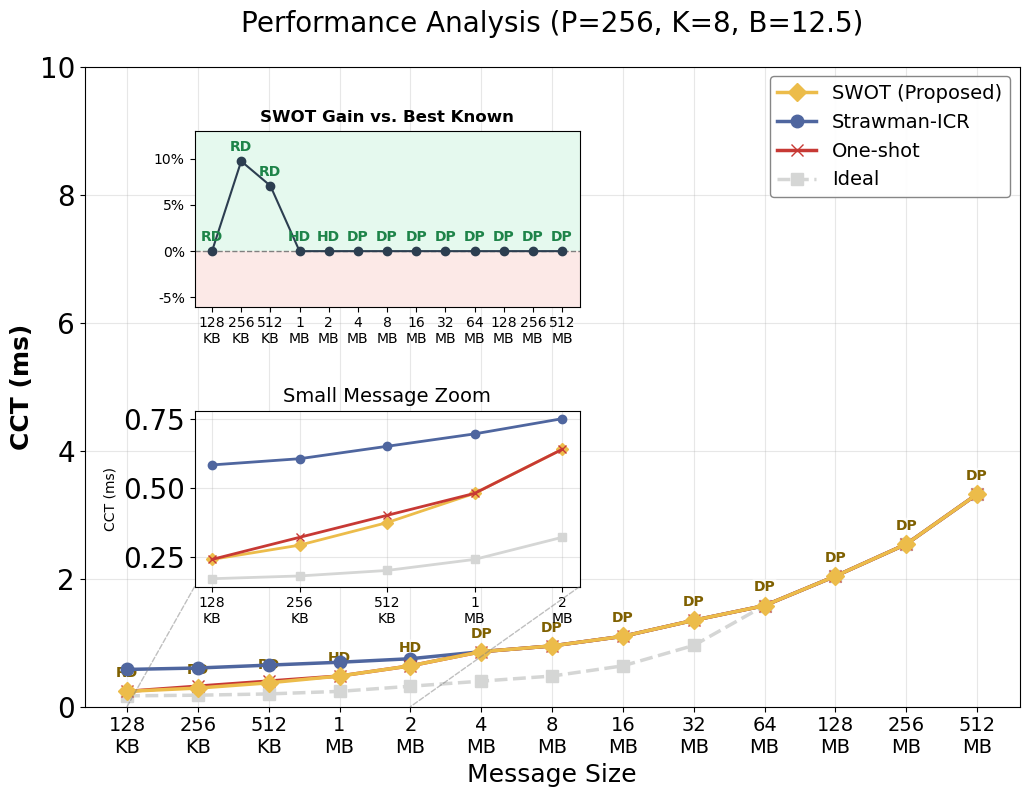

In [76]:
df = pd.read_csv("../logs/matrix_results-exp1.3-ar.csv")

# 预处理（极少量因为求解时间不足等而导致结果没有收敛，应退化为Strawman或one-shot策略）
# Preprocess: when optimized_cct > baseline_cct, use baseline_cct
df.loc[df["optimized_cct"] > df["baseline_cct"], "optimized_cct"] = df.loc[df["optimized_cct"] > df["baseline_cct"], "baseline_cct"]
# Preprocess: when optimized_cct > oneshot_cct, use oneshot_cct
df.loc[df["optimized_cct"] > df["oneshot_cct"], "optimized_cct"] = df.loc[df["optimized_cct"] > df["oneshot_cct"], "oneshot_cct"]

config_example = {"p": 256, "k": 8, "B": 12.5} 
comparison_algorithms = ['ar_having-doubling', 'ar_recursive-doubling', 'ar_ring', 'ar_dbt', 'ar_dbt_pipe']

draw_comprehensive_plot(
    df, 
    config_example, 
    alg_candidates=comparison_algorithms,
    zoom_range=(0, 5),       # Zoom 区域通常关注算法交接点附近
    gain_range=(0, 13),       # Gain 图覆盖从小消息到交接完成
    manual_ylim=10,        # 让它自动计算，或者根据 A2A 的延迟数量级手动指定 (例如 500)
    show_main_labels=True,   # 开启主图标注 (会显示 P, B)
    positions={
        'gain': [0.20, 0.60, 0.35, 0.22],
        'zoom': [0.20, 0.25, 0.35, 0.22]
    },
    
    save_filename='figures/exp1.3_ar.pdf'
)


##### K尝试 （暂时不用）

正在处理: P256-K8-B12.5...


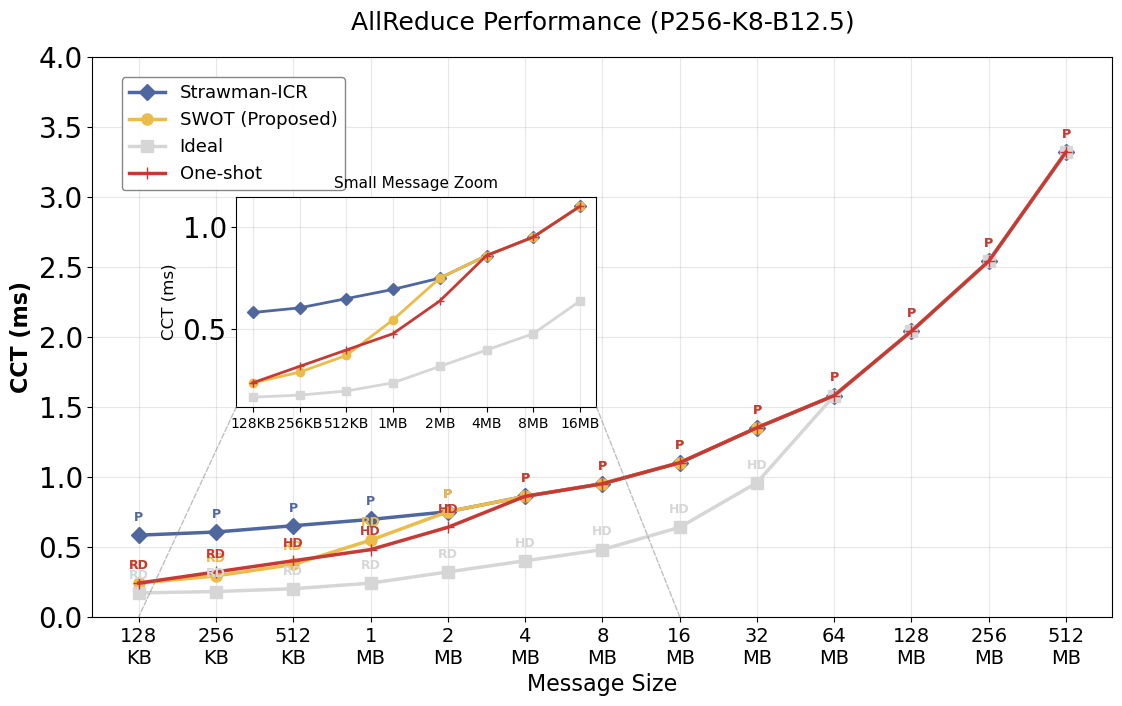

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
from matplotlib.patches import ConnectionPatch

# 样式配置（保持不变）
STYLE = {
    'SWOT':       {'c': "#ecbc4a", 'm': 'o', 'l': 'SWOT (Proposed)'},
    'Strawman':   {'c': "#4f669f", 'm': 'D', 'l': 'Strawman-ICR'},
    'Ideal':      {'c': '#d5d6d5', 'm': 's', 'l': 'Ideal'},
    'One-shot':   {'c': "#c73934", 'm': '+', 'l': 'One-shot'},
    'font_size': 14
}

# 算法名称缩写映射
ALGO_ABBR = {
    'ar_having-doubling': 'HD',
    'ar_recursive-doubling': 'RD',
    'ar_ring': 'R',
    'ar_dbt': 'D',
    'ar_dbt_pipe': 'P'
}

def format_size_label(mib_val):
    """将 MiB 值转换为 KB/MB 标签"""
    kb_val = mib_val * 1024
    if kb_val < 1024:
        return f"{kb_val:.0f}\nKB"
    else:
        return f"{kb_val/1024:.0f}\nMB"

def load_and_process_data(results_path, algorithms, target_params):
    """
    加载数据，筛选算法和参数，并计算每种CCT的最小值及其对应算法
    
    参数:
    -----------
    results_path : Path 或 str
        CSV文件路径
    algorithms : list
        要包含的算法名称列表
    target_params : dict
        包含 p, k, B 值的筛选字典
        
    返回:
    --------
    pandas.DataFrame
        包含最小值和算法标签的处理后DataFrame
    """
    df = pd.read_csv(results_path)
    
    # 筛选数据
    df_filtered = df[
        df['algorithm'].isin(algorithms) &
        (df['p'] == target_params['p']) &
        (df['k'] == target_params['k']) &
        (np.isclose(df['B'], target_params['B']))
    ].copy()
    
    if df_filtered.empty:
        print(f"警告: 未找到参数 {target_params} 的数据")
        return pd.DataFrame()
    
    # CCT列配置
    cct_columns = ['baseline_cct', 'optimized_cct', 'ideal_cct', 'oneshot_cct']
    
    # 按消息大小分组处理
    processed_rows = []
    for msg_size, group in df_filtered.groupby('message_mib'):
        row = {'message_mib': msg_size}
        
        for col in cct_columns:
            # 忽略0和NaN值
            valid_values = group[col].replace({0: np.nan}).dropna()
            if valid_values.empty:
                row[col] = np.nan
                row[f'{col}_label'] = ''
                continue
                
            min_val = valid_values.min()
            row[col] = min_val
            
            # 找出达到最小值的算法
            min_algos = group[group[col] == min_val]['algorithm'].unique()
            abbreviations = [ALGO_ABBR.get(algo, algo[:2]) for algo in min_algos]
            row[f'{col}_label'] = ','.join(sorted(abbreviations))
        
        processed_rows.append(row)
    
    result_df = pd.DataFrame(processed_rows)
    result_df.sort_values('message_mib', inplace=True)
    result_df.reset_index(drop=True, inplace=True)
    return result_df

def draw_combined_algo_plot(df_processed, title_str, zoom_idx_range=(0, 6), 
                            manual_ylim=None, use_log_y=False, 
                            inset_position=[0.22, 0.25, 0.25, 0.25],
                            save_fig_filename=None,
                            show_plot=True):
    """
    绘制跨算法最小CCT图，并在每个点标注算法
    
    参数:
    -----------
    df_processed : pandas.DataFrame
        处理后的DataFrame（包含最小值和算法标签）
    title_str : str
        图表标题
    zoom_idx_range : tuple
        缩放区域索引范围 (start_idx, end_idx)
    manual_ylim : float, 可选
        手动设置Y轴上限
    use_log_y : bool
        是否使用对数Y轴
    inset_position : list
        缩放图位置 [left, bottom, width, height]
    save_fig_filename : str, 可选
        保存文件路径
    show_plot : bool
        是否显示图表
    """
    if df_processed.empty:
        print("错误: 提供的DataFrame为空")
        return
    
    # 创建画布
    fig = plt.figure(figsize=(12, 7), dpi=100)
    plt.rcParams.update({'font.size': STYLE['font_size']})
    ax_main = fig.add_axes([0.1, 0.1, 0.85, 0.8])
    
    # 准备数据
    x_indices = np.arange(len(df_processed))
    x_labels = [format_size_label(s) for s in df_processed["message_mib"]]
    
    # 线条配置: (显示标签, 数据列名, 样式字典)
    line_configs = [
        (STYLE['Strawman']['l'], 'baseline_cct', STYLE['Strawman']),
        (STYLE['SWOT']['l'], 'optimized_cct', STYLE['SWOT']),
        (STYLE['Ideal']['l'], 'ideal_cct', STYLE['Ideal']),
        (STYLE['One-shot']['l'], 'oneshot_cct', STYLE['One-shot']),
    ]
    
    # 绘制所有线条
    lines_plotted = []
    for label, col_name, style in line_configs:
        y_values = df_processed[col_name].replace({0: np.nan}).values
        
        # 如果全为NaN则跳过
        if np.all(np.isnan(y_values)):
            continue
            
        # 绘制主线
        line = ax_main.plot(x_indices, y_values, c=style['c'], marker=style['m'], 
                            lw=2.5, ms=8, label=label)[0]
        lines_plotted.append((col_name, style, line))
    
    # 设置坐标轴
    ax_main.set_xticks(x_indices)
    ax_main.set_xticklabels(x_labels, fontsize=14)
    ax_main.set_xlabel('Message Size', fontsize=16)
    ax_main.set_ylabel('CCT (ms)', fontsize=16, fontweight='bold')
    
    # 设置Y轴范围和比例
    if use_log_y:
        ax_main.set_yscale('log')
        ax_main.set_ylim(bottom=1e-6)  # 避免0在对数尺度上的问题
    else:
        if manual_ylim is None:
            all_vals = []
            for col_name, _, _ in lines_plotted:
                all_vals.extend(df_processed[col_name].dropna().values)
            if all_vals:
                max_val = max(all_vals)
                ax_main.set_ylim(0, max_val * 1.2)
        else:
            ax_main.set_ylim(0, manual_ylim)
    
    # 标题和网格
    ax_main.set_title(title_str, fontsize=18, pad=20)
    ax_main.grid(True, linestyle='-', alpha=0.3)
    
    # 图例
    if lines_plotted:
        ax_main.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), 
                       fontsize=13, frameon=True, edgecolor='gray', 
                       facecolor='white', framealpha=0.95)
    
    # 获取Y轴范围用于计算标注偏移
    y_min, y_max = ax_main.get_ylim()
    offset_ratio = 0.02 if not use_log_y else 0.1
    
    # 添加算法标注
    for col_name, style, _ in lines_plotted:
        for i, (_, row) in enumerate(df_processed.iterrows()):
            cct_val = row[col_name]
            if pd.isna(cct_val) or cct_val <= 0:
                continue
                
            algo_label = row[f'{col_name}_label']
            if pd.isna(algo_label) or algo_label == '':
                continue
            
            # 计算标注位置
            if use_log_y:
                y_offset = cct_val * (1 + offset_ratio)
            else:
                y_offset = cct_val + (y_max - y_min) * offset_ratio
            
            ax_main.annotate(algo_label,
                           xy=(i, cct_val),
                           xytext=(i, y_offset),
                           ha='center', va='bottom',
                           fontsize=9, fontweight='bold',
                           color=style['c'])
    
    # 绘制缩放图
    zoom_start, zoom_end = zoom_idx_range
    if zoom_end > len(df_processed):
        zoom_end = len(df_processed)
    
    x_zoom = x_indices[zoom_start:zoom_end]
    
    ax_ins = fig.add_axes(inset_position)
    
    for col_name, style, _ in lines_plotted:
        y_values = df_processed[col_name].replace({0: np.nan}).values
        y_zoom = y_values[zoom_start:zoom_end]
        ax_ins.plot(x_zoom, y_zoom, c=style['c'], marker=style['m'], lw=2)
    
    ax_ins.set_xticks(x_zoom)
    ax_ins.set_xticklabels([l.replace('\n', '') for l in x_labels[zoom_start:zoom_end]], 
                           fontsize=10)
    ax_ins.set_ylabel('CCT (ms)', fontsize=12)
    ax_ins.grid(True, alpha=0.3)
    ax_ins.set_title("Small Message Zoom", fontsize=11)
    ax_ins.set_facecolor('white')
    
    # 连接线
    y_bottom_main = ax_main.get_ylim()[0]
    con1 = ConnectionPatch(xyA=(0, 0), xyB=(zoom_start, y_bottom_main), 
                           coordsA="axes fraction", coordsB="data",
                           axesA=ax_ins, axesB=ax_main, 
                           color="gray", linestyle="--", alpha=0.5)
    con2 = ConnectionPatch(xyA=(1, 0), xyB=(zoom_end-1, y_bottom_main), 
                           coordsA="axes fraction", coordsB="data",
                           axesA=ax_ins, axesB=ax_main, 
                           color="gray", linestyle="--", alpha=0.5)
    fig.add_artist(con1)
    fig.add_artist(con2)
    
    # 保存
    if save_fig_filename:
        save_path = Path(save_fig_filename)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_fig_filename, bbox_inches='tight')
    
    if show_plot:
        plt.show()
    else:
        plt.close(fig)

# ==========================================
# 使用示例
# ==========================================
if __name__ == "__main__":
    # 配置
    results_path = Path("../logs/matrix_results-exp1.3-ar.csv")
    algorithms = ['ar_having-doubling', 'ar_recursive-doubling', 'ar_ring', 'ar_dbt', 'ar_dbt_pipe']
    
    # 实验配置（可根据需求修改）
    configs = [
        # {"p": 16, "k": 4, "B": 25, "name": "P16-K4-B25", "ylim": None},
        {"p": 256, "k": 8, "B": 12.5, "name": "P256-K8-B12.5", "ylim": 4},
        # 添加更多配置...
    ]
    
    # 批量生成图表
    for cfg in configs:
        print(f"正在处理: {cfg['name']}...")
        
        # 加载并处理数据
        df_processed = load_and_process_data(results_path, algorithms, cfg)
        
        if df_processed.empty:
            continue
        
        # 绘制图表
        draw_combined_algo_plot(
            df_processed,
            title_str=f"AllReduce Performance ({cfg['name']})",
            zoom_idx_range=(0, 8),  # 可调整为 (0, 9) 等
            manual_ylim=cfg.get("ylim"),
            inset_position=[0.22, 0.4, 0.3, 0.3],  # 可调位置
            save_fig_filename=f"figures/exp13-{cfg['name']}.pdf",
            show_plot=True
        )

----

### All-to-All Apples-to-Apples Comparison

##### A2A数据注释

数据组成：

- p=9  `results-exp1.3-a2a-9.csv`
    1. `exp1.3-a2a_bruck.toml` 计算
    2. `exp1.1-pair-2.toml` 复用（直接复制`matrix_results-exp1.1-pair-2.csv`粘贴过来）

- p=256 `results-exp1.3-a2a.csv`
    1. `exp1.3-a2a_pair.toml` 计算，筛选（有些是`fail`的数据）追加
    2. `exp1.1-hd+bruck-2.toml`(bruck部分) ，使用`pd`筛选追加复用

对于 p=256 的数据获取如下（p=9直接复制粘贴了）

In [112]:
# 从 "../logs/results-exp1.3-a2a.csv" 中读取筛选写入到 "../logs/results-exp1.3-a2a.csv"
results_path = Path("../logs/matrix_results-exp1.3-a2a.csv")
df = pd.read_csv(results_path)

target_config = {
    "status": "success",
    "alg": "a2a_pairwise",
    "p": 256,
    "k": 8,
    "B": 12.5
}

subdf = df[(df["algorithm"] == target_config["alg"]) & 
            (df["p"] == target_config["p"]) & 
            (df["k"] == target_config["k"]) & 
            (df["status"] == target_config["status"]) & 
            (np.isclose(df["B"], target_config["B"]))].copy()

len(subdf)
# # 追加
subdf.to_csv("../logs/results-exp1.3-a2a.csv", mode='a', header=False, index=False)

In [92]:
# 从 "../matrix_results-exp1.1-hd+bruck-2.csv" 中读取筛选写入到 "../logs/results-exp1.3-a2a.csv"
results_path = Path("../logs/matrix_results-exp1.1-hd+bruck-2.csv")
df = pd.read_csv(results_path)

target_config = {
    "status": "success",
    "alg": "a2a_bruck",
    "p": 256,
    "k": 8,
    "B": 12.5
}

subdf = df[(df["algorithm"] == target_config["alg"]) & 
            (df["p"] == target_config["p"]) & 
            (df["k"] == target_config["k"]) & 
            (df["status"] == target_config["status"]) & 
            (np.isclose(df["B"], target_config["B"]))].copy()

len(subdf)
# # 追加
subdf.to_csv("../logs/results-exp1.3-a2a.csv", mode='a', header=False, index=False)

#### 绘图 （复用AR的部分函数）

1. 更新映射字典 (AllReduce -> Alltoall)

In [114]:
# 这里的 Key 必须与 CSV 中 'algorithm' 列的值一致
ALG_SHORT_MAP.update({
    'a2a_pairwise': 'P',
    'a2a_bruck': 'B',
})

2. 读入数据(9)

In [78]:
results_path = Path("../logs/results-exp1.3-a2a-9.csv")
if not results_path.exists():
    print(f"Error: File not found at {results_path}")
else:
    df = pd.read_csv(results_path)
    print("Data Loaded. Columns:", df.columns)
    
    # 打印一下文件中包含的参数组合，方便你填入下面的 config
    available_params = df[['p', 'k', 'B']].drop_duplicates()
    print("\nAvailable Configs in CSV:")
    print(available_params)

# 预处理（极少量因为求解时间不足等而导致结果没有收敛，应退化为Strawman或one-shot策略）
# Preprocess: when optimized_cct > baseline_cct, use baseline_cct
df.loc[df["optimized_cct"] > df["baseline_cct"], "optimized_cct"] = df.loc[df["optimized_cct"] > df["baseline_cct"], "baseline_cct"]
# Preprocess: when optimized_cct > oneshot_cct, use oneshot_cct
df.loc[df["optimized_cct"] > df["oneshot_cct"], "optimized_cct"] = df.loc[df["optimized_cct"] > df["oneshot_cct"], "oneshot_cct"]

# 定义要对比的算法
comparison_algos_a2a = ['a2a_pairwise', 'a2a_bruck']

# 定义目标配置 (请根据上面 print 出来的结果修改)
target_config_a2a = {
    "p": 9, 
    "k": 8,     # 如果你的 A2A 数据里没有 k 列，或者 k 不重要，请确认 dataframe 里是否有这个值
    "B": 12.5   # 假设值
}

# 检查一下这个配置有没有数据
check_df = df[
    (df["p"] == target_config_a2a["p"]) & 
    (df["k"] == target_config_a2a["k"]) & 
    (np.isclose(df["B"], target_config_a2a["B"]))
]
print(f"\nData points found for config: {len(check_df)}")

Data Loaded. Columns: Index(['timestamp', 'matrix_id', 'run_id', 'config_path', 'algorithm',
       'message_mib', 'solver', 'solver_gap', 'solver_time_limit', 'k',
       'T_reconf', 'T_lat', 'B', 'p', 'status', 'returncode',
       'duration_seconds', 'optimized_cct', 'baseline_cct', 'oneshot_cct',
       'ideal_cct', 'improvement_over_baseline_pct', 'metrics_path', 'hash'],
      dtype='object')

Available Configs in CSV:
    p  k     B
0   8  8  12.5
13  9  8  12.5

Data points found for config: 13


3. 绘图

Figure saved to figures/exp1.3_a2a_9.pdf


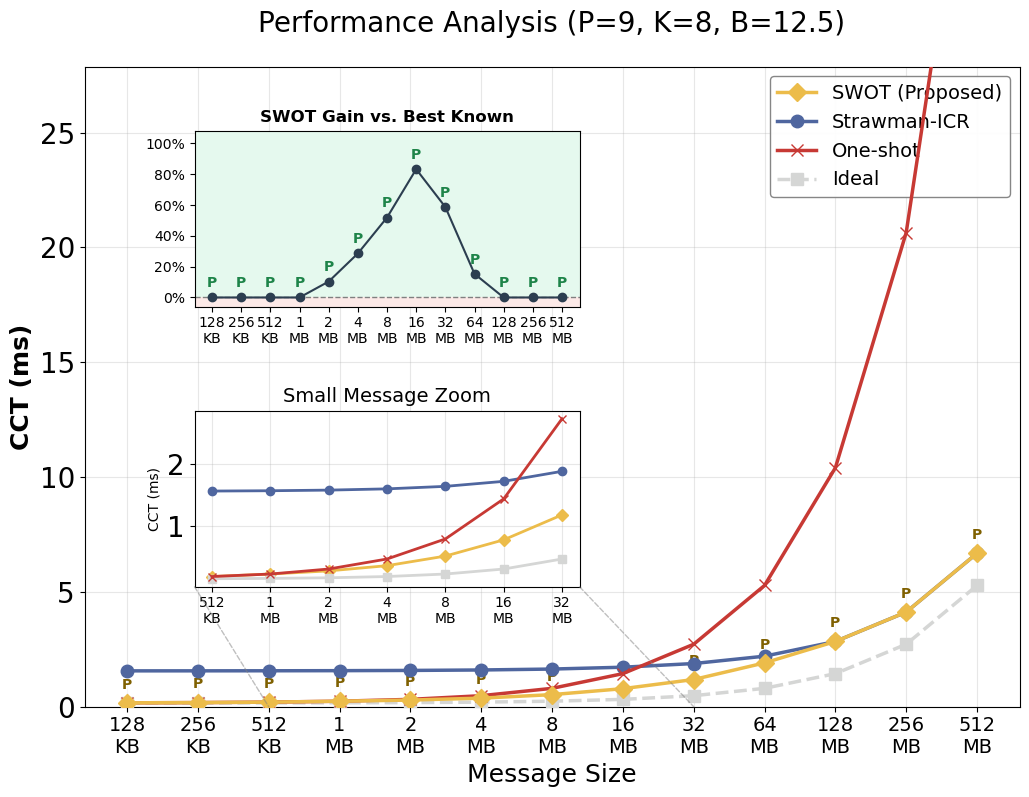

In [79]:
# 复用之前的绘图函数
draw_comprehensive_plot(
    df, 
    target_config_a2a, 
    alg_candidates=comparison_algos_a2a,
    
    # --- 视觉微调 ---
    zoom_range=(2, 9),       # Zoom 区域通常关注算法交接点附近
    gain_range=(0, 13),       # Gain 图覆盖从小消息到交接完成
    manual_ylim=None,        # 让它自动计算，或者根据 A2A 的延迟数量级手动指定 (例如 500)
    show_main_labels=True,   # 开启主图标注 (会显示 P, B)
    positions={
        'gain': [0.20, 0.60, 0.35, 0.22],
        'zoom': [0.20, 0.25, 0.35, 0.22]
    },
    
    save_filename='figures/exp1.3_a2a_9.pdf'
)

2. 读入数据(256)

In [115]:
results_path = Path("../logs/results-exp1.3-a2a.csv")
if not results_path.exists():
    print(f"Error: File not found at {results_path}")
else:
    df = pd.read_csv(results_path)
    print("Data Loaded. Columns:", df.columns)
    
    # 打印一下文件中包含的参数组合，方便你填入下面的 config
    available_params = df[['p', 'k', 'B']].drop_duplicates()
    print("\nAvailable Configs in CSV:")
    print(available_params)

# 预处理（极少量因为求解时间不足等而导致结果没有收敛，应退化为Strawman或one-shot策略）
# Preprocess: when optimized_cct > baseline_cct, use baseline_cct
df.loc[df["optimized_cct"] > df["baseline_cct"], "optimized_cct"] = df.loc[df["optimized_cct"] > df["baseline_cct"], "baseline_cct"]
# Preprocess: when optimized_cct > oneshot_cct, use oneshot_cct
df.loc[df["optimized_cct"] > df["oneshot_cct"], "optimized_cct"] = df.loc[df["optimized_cct"] > df["oneshot_cct"], "oneshot_cct"]

# 定义要对比的算法
comparison_algos_a2a = ['a2a_pairwise', 'a2a_bruck']

# 定义目标配置 (请根据上面 print 出来的结果修改)
target_config_a2a = {
    "p": 256, 
    "k": 8,     # 如果你的 A2A 数据里没有 k 列，或者 k 不重要，请确认 dataframe 里是否有这个值
    "B": 12.5   # 假设值
}

# 检查一下这个配置有没有数据
check_df = df[
    (df["p"] == target_config_a2a["p"]) & 
    (df["k"] == target_config_a2a["k"]) & 
    (np.isclose(df["B"], target_config_a2a["B"]))
]
print(f"\nData points found for config: {len(check_df)}")

Data Loaded. Columns: Index(['timestamp', 'matrix_id', 'run_id', 'config_path', 'algorithm',
       'message_mib', 'solver', 'solver_gap', 'solver_time_limit', 'k',
       'T_reconf', 'T_lat', 'B', 'p', 'status', 'returncode',
       'duration_seconds', 'optimized_cct', 'baseline_cct', 'oneshot_cct',
       'ideal_cct', 'improvement_over_baseline_pct', 'metrics_path', 'hash'],
      dtype='object')

Available Configs in CSV:
     p  k     B
0  256  8  12.5

Data points found for config: 41


3. 绘图

Figure saved to figures/exp1.3_a2a_256.pdf


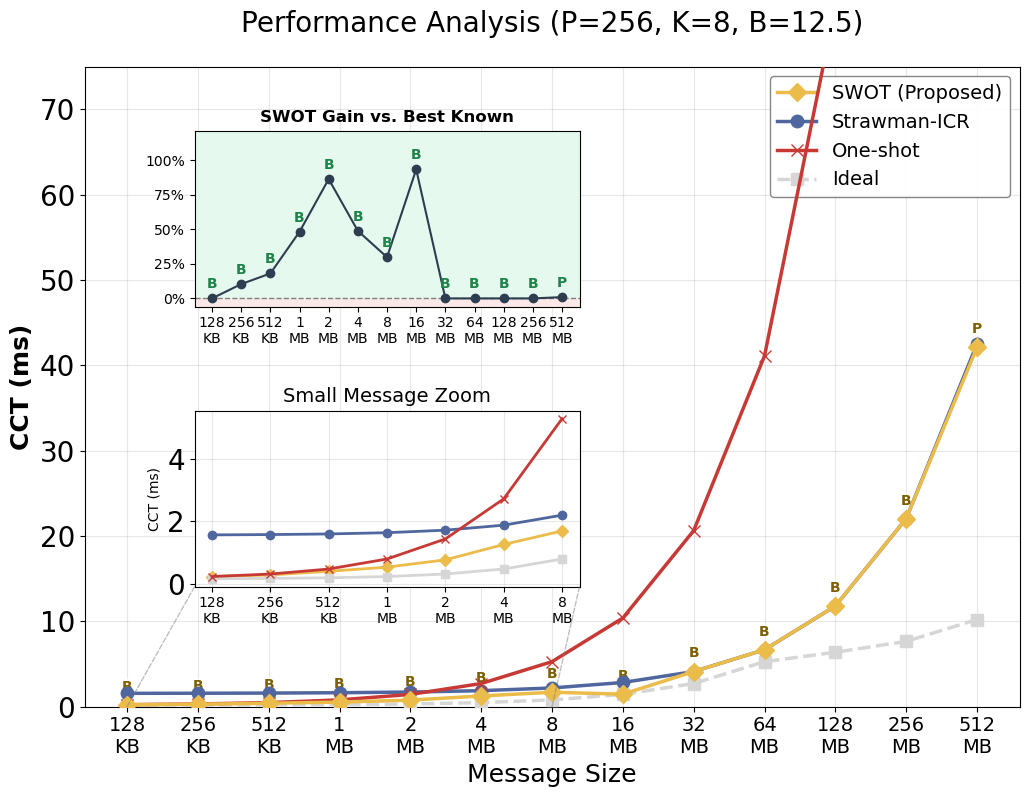

In [116]:
# 复用之前的绘图函数
draw_comprehensive_plot(
    df, 
    target_config_a2a, 
    alg_candidates=comparison_algos_a2a,
    
    # --- 视觉微调 ---
    zoom_range=(0, 7),       # Zoom 区域通常关注算法交接点附近
    gain_range=(0, 13),       # Gain 图覆盖从小消息到交接完成
    manual_ylim=75,        # 让它自动计算，或者根据 A2A 的延迟数量级手动指定 (例如 500)
    show_main_labels=True,   # 开启主图标注 (会显示 P, B)
    positions={
        'gain': [0.20, 0.60, 0.35, 0.22],
        'zoom': [0.20, 0.25, 0.35, 0.22]
    },
    
    save_filename='figures/exp1.3_a2a_256.pdf'
)

论文数据

In [ ]:
# 调试数据
df_ar = pd.read_csv("../logs/matrix_results-exp1.3-ar.csv")
df_a2a = pd.read_csv("../logs/results-exp1.3-a2a.csv")

# 预处理（极少量因为求解时间不足等而导致结果没有收敛，应退化为Strawman或one-shot策略）
# Preprocess: when optimized_cct > baseline_cct, use baseline_cct
df_ar.loc[df_ar["optimized_cct"] > df_ar["baseline_cct"], "optimized_cct"] = df_ar.loc[df_ar["optimized_cct"] > df_ar["baseline_cct"], "baseline_cct"]
df_ar.loc[df_ar["optimized_cct"] > df_ar["oneshot_cct"], "optimized_cct"] = df_ar.loc[df_ar["optimized_cct"] > df_ar["oneshot_cct"], "oneshot_cct"]

df_a2a.loc[df_a2a["optimized_cct"] > df_a2a["baseline_cct"], "optimized_cct"] = df_a2a.loc[df_a2a["optimized_cct"] > df_a2a["baseline_cct"], "baseline_cct"]
df_a2a.loc[df_a2a["optimized_cct"] > df_a2a["oneshot_cct"], "optimized_cct"] = df_a2a.loc[df_a2a["optimized_cct"] > df_a2a["oneshot_cct"], "oneshot_cct"]

aconfig_example = {"p": 256, "k": 8, "B": 12.5} 

comparison_ar_algorithms = ['ar_having-doubling', 'ar_recursive-doubling', 'ar_ring', 'ar_dbt', 'ar_dbt_pipe']
plot_ar_df = prepare_data_v2(df_ar, aconfig_example, comparison_ar_algorithms)
print( plot_ar_df.loc[:, ['message_mib', 'gain_pct']] )

comparison_a2a_algorithms = ['a2a_pairwise', 'a2a_bruck']
plot_a2a_df = prepare_data_v2(df_a2a, aconfig_example, comparison_a2a_algorithms)

plot_a2a_df.loc[:, ['message_mib', 'gain_pct']]

    message_mib      gain_pct
0         0.125  4.440892e-14
1         0.250  9.714284e+00
2         0.500  7.059153e+00
3         1.000  0.000000e+00
4         2.000  0.000000e+00
5         4.000  0.000000e+00
6         8.000  0.000000e+00
7        16.000  0.000000e+00
8        32.000  0.000000e+00
9        64.000  0.000000e+00
10      128.000  0.000000e+00
11      256.000  0.000000e+00
12      512.000  0.000000e+00


,message_mib,gain_pct
0,0.125,4.440892e-14
1,0.250,1.034483e+01
2,0.500,1.803279e+01
3,1.000,4.814815e+01
4,2.000,8.620690e+01
5,4.000,4.878247e+01
6,8.000,2.976799e+01
7,16.000,9.319725e+01
8,32.000,0.000000e+00
9,64.000,0.000000e+00


---
# 设置类型2：探究调节变量对“自变量作用于因变量”的基本影响

## 实验2.1：不同OCS数量对方案(作用于DV)的影响

|`algorithms`|`k, B`|`m`|`p`|`solver_time_limit`|
|-|-|-|-|-|
|hd, bruck    pairwise|2, 50|[0.125, 0.5, 2.0, 8.0, 32.0, 128.0, 512.0]  |256  |120    |
||4, 25||||
||8, 12.5||||


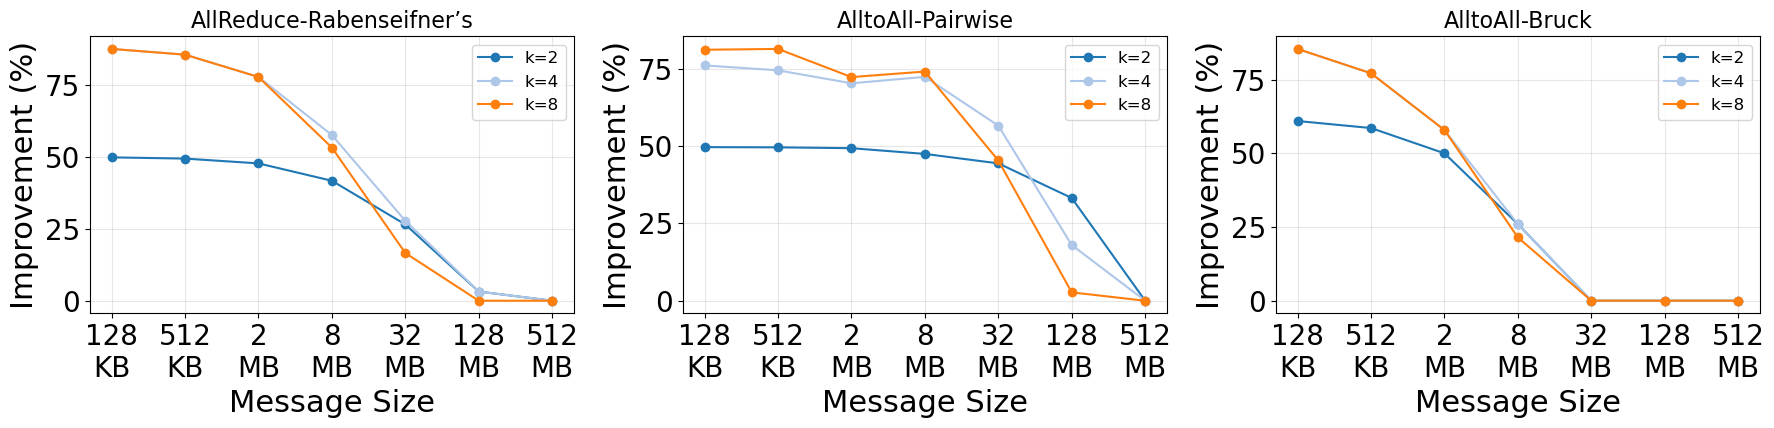

In [125]:
# results_path = Path("../logs/matrix_results-m32_sweep_msg+k.csv")
results_path = Path("../logs/matrix_results-m32_sweep_msg+k-b.csv")
df = pd.read_csv(results_path)

alg_labels = {
'rs_having-doubling': 'ReduceScatter-Rabenseifner’s',
'ar_having-doubling': 'AllReduce-Rabenseifner’s',
'a2a_bruck': 'AlltoAll-Bruck',
'a2a_pairwise': 'AlltoAll-Pairwise'
}

# 预处理（极少量因为求解时间不足等而导致结果没有收敛，应退化为Strawman或one-shot策略）
df.loc[df["optimized_cct"] > df["baseline_cct"], "optimized_cct"] = df.loc[df["optimized_cct"] > df["baseline_cct"], "baseline_cct"]
df.loc[df["optimized_cct"] > df["oneshot_cct"], "optimized_cct"] = df.loc[df["optimized_cct"] > df["oneshot_cct"], "oneshot_cct"]

algs = ['ar_having-doubling', 'a2a_pairwise', 'a2a_bruck']
solver_time_limit = [120]

# 只画 Improvement (%)，1 行 3 列
metric = 'improvement_pct'
ylabel = 'Improvement (%)'

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex='col')
colors = plt.cm.tab20.colors

for col, alg_name in enumerate(algs):
    ax = axes[col]
    # 根据 alg_labels 设置子图标题
    raw_title = alg_labels.get(alg_name, alg_name)
    # 可读性更好：在中横线处换行
    title = raw_title #.replace('-', '\n')

    subdf = df[df["algorithm"] == alg_name].copy()
    subdf = subdf[subdf["status"] == "success"].copy()
    subdf = subdf[subdf["solver_time_limit"].isin(solver_time_limit)].copy()
    if subdf.empty:
        ax.set_title(f"{title}\n(no data)")
        ax.set_xlabel('Message Size')
        ax.set_xscale('log', base=2)
        ax.grid(alpha=0.3)
        continue

    df_pivot = subdf.pivot_table(
        values=['optimized_cct', 'baseline_cct', 'ideal_cct'],
        index=['message_mib', 'k', 'p'],
        aggfunc='first'
    ).reset_index()
    df_pivot['improvement_pct'] = (
        (df_pivot['baseline_cct'] - df_pivot['optimized_cct']) /
        df_pivot['baseline_cct']
    ) * 100

    # 横坐标：Message size，数值和单位分两行
    msg_sizes = np.sort(df_pivot['message_mib'].unique())
    msg_kb = msg_sizes * 1024
    labels = []
    for size in msg_kb:
        if size < 1024:
            labels.append(f'{size:.0f}\nKB')
        else:
            labels.append(f'{size/1024:.0f}\nMB')

    unique_k = sorted(df_pivot['k'].unique())
    for i, k_val in enumerate(unique_k):
        grp = df_pivot[df_pivot['k'] == k_val].sort_values('message_mib')
        ax.plot(
            grp['message_mib'], grp[metric],
            marker='o', linestyle='-', color=colors[i % len(colors)],
            label=f'k={k_val}'
        )

    ax.set_xlabel('Message Size')
    ax.set_xscale('log', base=2)
    ax.set_xticks(msg_sizes)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=16)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('figures/exp2.1_impact_k.pdf', bbox_inches='tight')
plt.show()

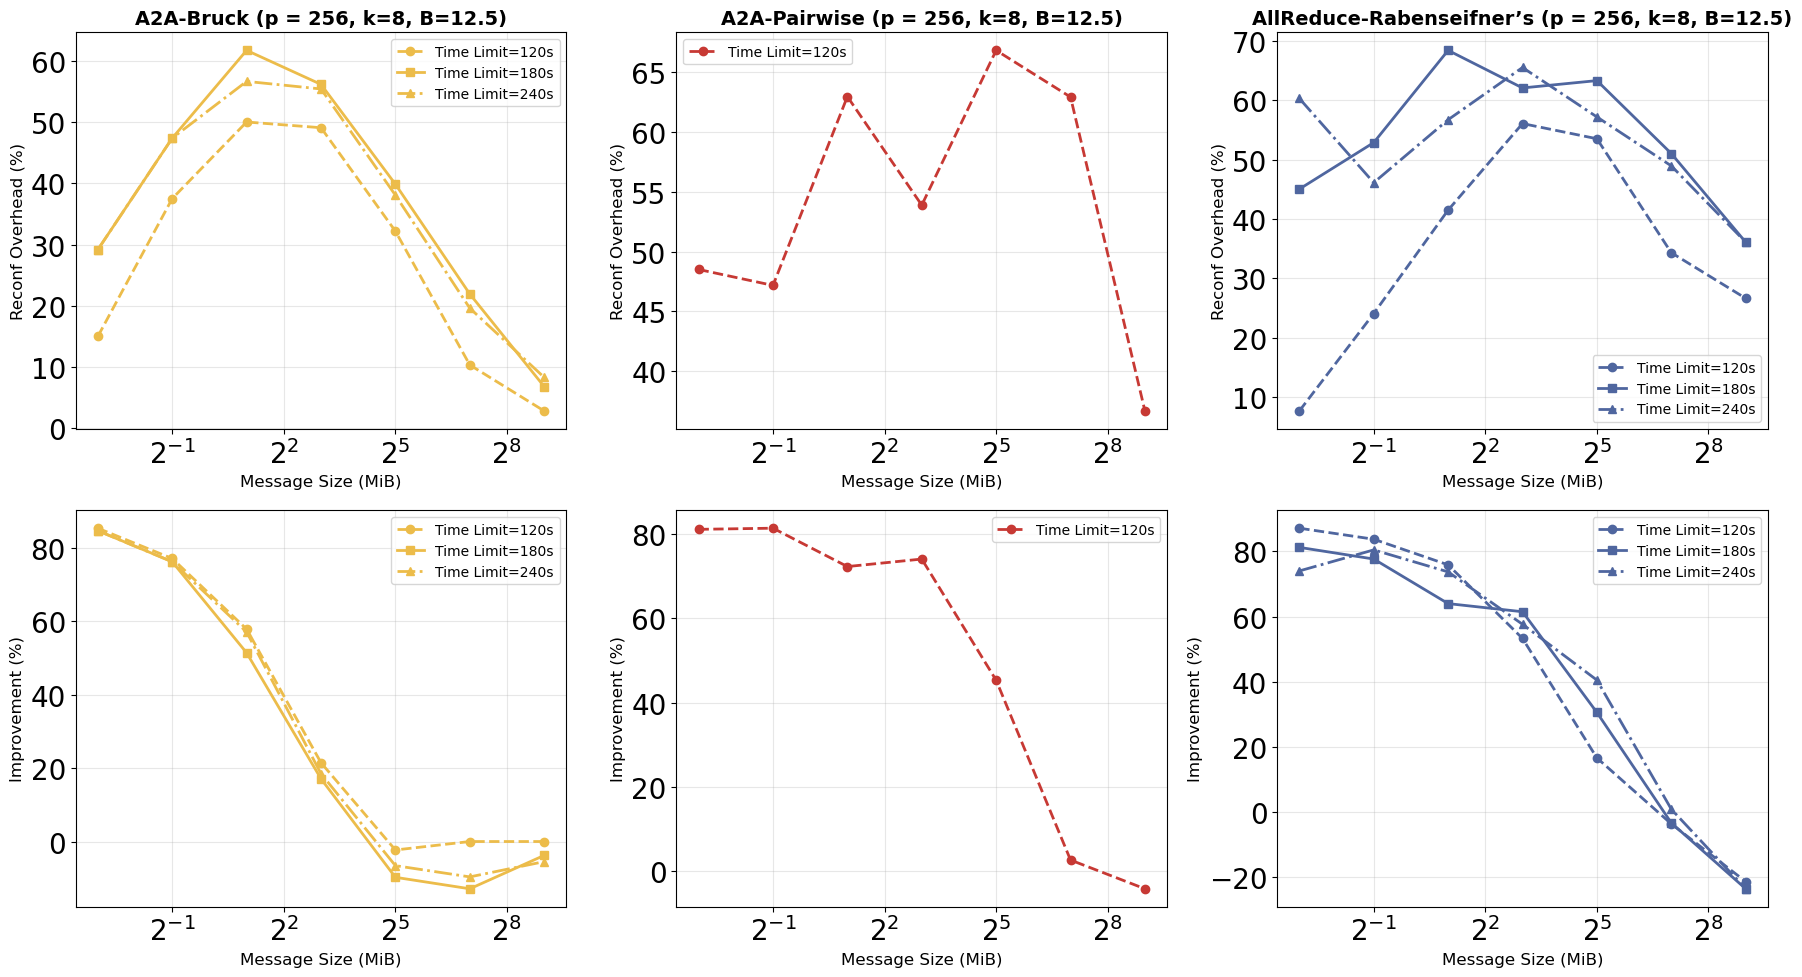

In [256]:
results_path = Path("../logs/matrix_results-m32_sweep_msg+k-b.csv")
df = pd.read_csv(results_path)

# Filter for k=8 and B=12.5
subdf = df[(df["k"] == 8) & (np.isclose(df["B"], 12.5))].copy()
subdf = subdf[subdf["status"] == "success"].copy()

# Calculate metrics
subdf["overhead_pct"] = ((subdf["optimized_cct"] - subdf["ideal_cct"]) / subdf["optimized_cct"]) * 100
subdf["improvement_pct"] = ((subdf["baseline_cct"] - subdf["optimized_cct"]) / subdf["baseline_cct"]) * 100

# Get unique solver_time_limit values and algorithms
unique_time_limits = sorted(subdf["solver_time_limit"].unique())
unique_algs = sorted(subdf["algorithm"].unique())

# Algorithm color mapping (reuse existing)
alg_colors = {
    'ar_having-doubling': '#4f669f',
    'a2a_pairwise': '#c73934', 
    'a2a_bruck': '#ecbc4a'
}


# Create figure with 2 rows x 3 columns (2 metrics x 3 algorithms)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    ('overhead_pct', 'Reconf Overhead (%)'),
    ('improvement_pct', 'Improvement (%)')
]

# Define line styles for different time limits
time_limit_styles = {
    120: {'linestyle': '--', 'marker': 'o', 'label': 'Time Limit=120s'},
    180: {'linestyle': '-', 'marker': 's', 'label': 'Time Limit=180s'},
    240: {'linestyle': '-.', 'marker': '^', 'label': 'Time Limit=240s'}
}

for col, alg in enumerate(unique_algs):
    for row, (metric, ylabel) in enumerate(metrics):
        ax = axes[row, col]
        
        # Plot data for each solver_time_limit
        for time_limit in unique_time_limits:
            data = subdf[(subdf["algorithm"] == alg) & 
                        (subdf["solver_time_limit"] == time_limit)].sort_values("message_mib")
            
            if data.empty:
                continue
            
            color = alg_colors.get(alg, 'gray')
            style = time_limit_styles[time_limit]
            
            ax.plot(data["message_mib"], data[metric],
                    marker=style['marker'], linestyle=style['linestyle'], 
                    color=color, label=style['label'],
                    linewidth=2, markersize=6)
        
        # Configure axes
        ax.set_xscale('log', base=2)
        ax.set_xlabel('Message Size (MiB)', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Title only on top row
        if row == 0:
            alg_display = alg_labels.get(alg, alg)
            ax.set_title(f'{alg_display} (p = 256, k=8, B=12.5)', fontsize=14, fontweight='bold')
        
        # Legend on all subplots for clarity
        ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('figures/k8_B12.5_solver_time_comparison_2x3.pdf', bbox_inches='tight')
plt.show()

---

## 实验2.2：不同重构时延对方案(作用于DV)的影响

|`algorithms`|`T_reconf`|`k, B`|`m`|`p`|
|-|-|-|-|-|
|hd, bruck    pairwise  |0.02|(4, 25)  |[0.125, 0.5, 2.0, 8.0, 32.0, 128.0, 512.0]    |256    |
||0.2||||
||2.0||||
||20.0||||


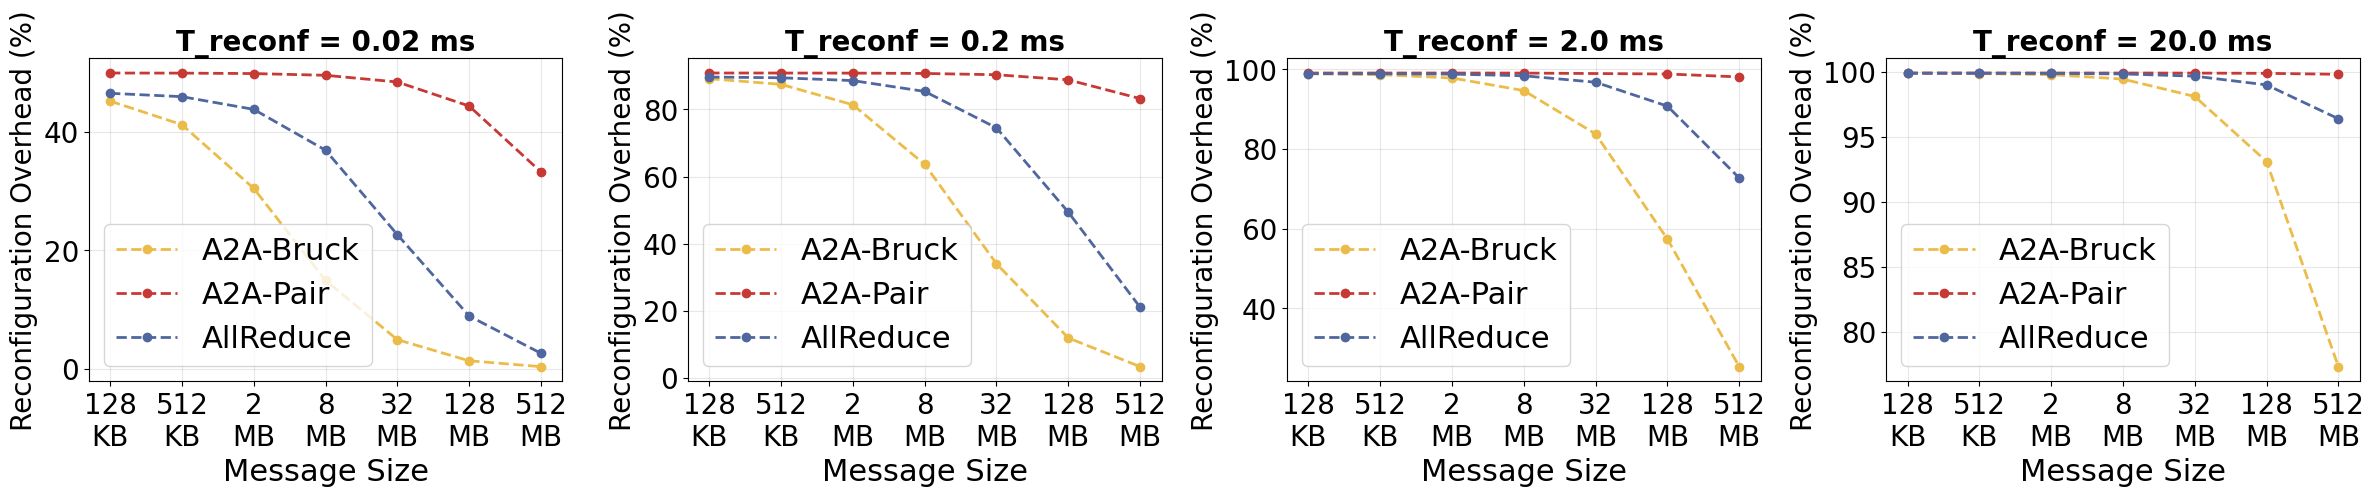

In [106]:
results_path = Path("../logs/matrix_results-m32_sweep_msg+Tr.csv")
df = pd.read_csv(results_path)

df = df[df["status"] == "success"].copy()
df["message_mib"] = df["message_mib"].astype(float)

df = df[df["B"] == 25].copy()  # B=25

df.sort_values("message_mib", inplace=True)

# Calculate metrics
# df["overhead_pct"] = ((df["optimized_cct"] - df["ideal_cct"]) / df["optimized_cct"]) * 100
df["overhead_pct"] = ((df["baseline_cct"] - df["ideal_cct"]) / df["baseline_cct"]) * 100
df["improvement_pct"] = ((df["baseline_cct"] - df["optimized_cct"]) / df["baseline_cct"]) * 100

# Get unique T_reconf values and algorithms
unique_Tr = sorted(df["T_reconf"].unique())
unique_algs = sorted(df["algorithm"].unique())

# 横坐标：Message size，单位自动用KB/MB，数值与单位分行
msg_sizes = np.sort(df["message_mib"].unique())
msg_kb = msg_sizes * 1024
x_labels = []
for size in msg_kb:
    if size < 1024:
        x_labels.append(f"{size:.0f}\nKB")
    else:
        x_labels.append(f"{size/1024:.0f}\nMB")

# Color mapping for algorithms
alg_colors = {
    'ar_having-doubling': '#4f669f',
    'a2a_pairwise': '#c73934',
    'a2a_bruck': '#ecbc4a'
}

alg_labels = {
    'ar_having-doubling': 'AllReduce',
    'a2a_pairwise': 'A2A-Pair',
    'a2a_bruck': 'A2A-Bruck'
}

# Create figure with 1 row x 4 columns (4 T_reconf values, only overhead_pct)
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for col, Tr_val in enumerate(unique_Tr):
    ax = axes[col]
    subdf = df[df["T_reconf"] == Tr_val]

    for alg in unique_algs:
        alg_data = subdf[subdf["algorithm"] == alg].sort_values("message_mib")
        if alg_data.empty:
            continue

        color = alg_colors.get(alg, 'gray')
        label = alg_labels.get(alg, alg)

        ax.plot(
            alg_data["message_mib"],
            alg_data["overhead_pct"],
            marker='o',
            linestyle='--',
            color=color,
            label=label,
            linewidth=2,
            markersize=6,
        )

    # Configure axes
    ax.set_xscale('log', base=2)
    ax.set_xticks(msg_sizes)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel('Message Size', fontsize=22)
    ax.set_ylabel('Reconfiguration Overhead (%)', fontsize=20)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'T_reconf = {Tr_val} ms', fontsize=20, fontweight='bold')
    ax.legend(loc='best', fontsize=22)
plt.tight_layout()
plt.savefig('figures/exp2.2_impact_Treconf.pdf', bbox_inches='tight')
plt.show()


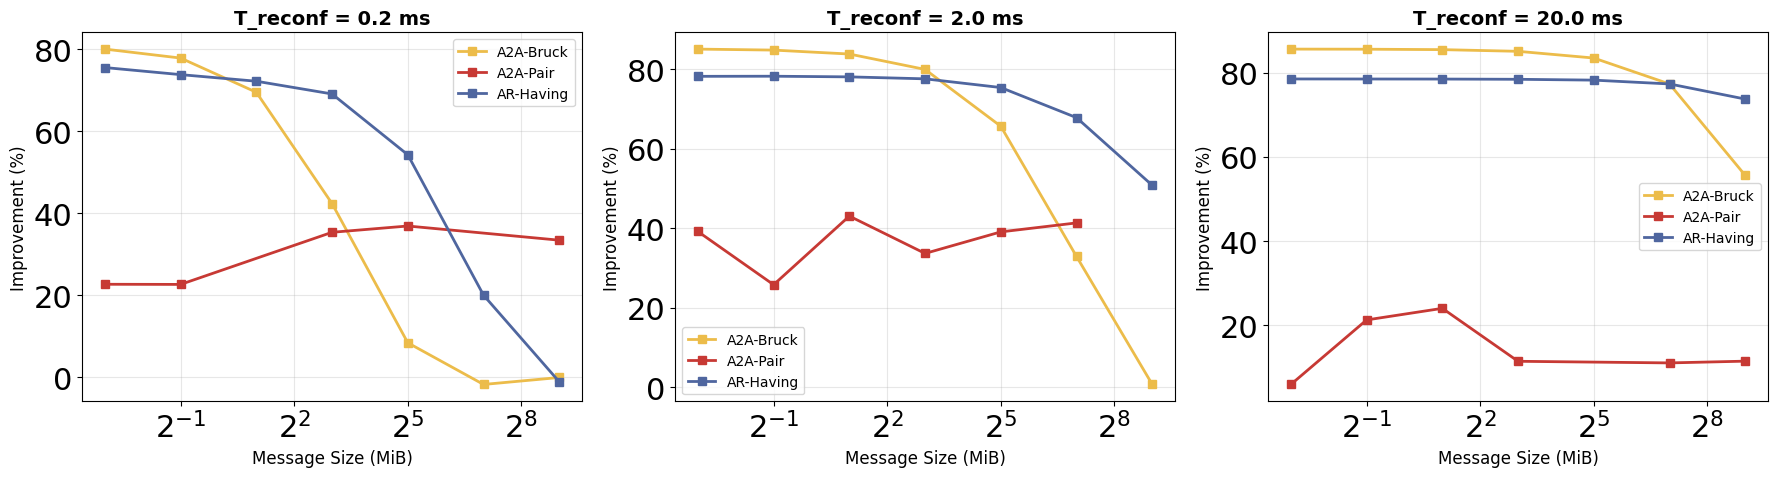

In [104]:
results_path = Path("../logs/matrix_results-m32_sweep_msg+Tr.csv")
df = pd.read_csv(results_path)
df = df[df["status"] == "success"].copy()
df["message_mib"] = df["message_mib"].astype(float)
df.sort_values("message_mib", inplace=True)

# Calculate improvement metric only
df["improvement_pct"] = ((df["baseline_cct"] - df["optimized_cct"]) / df["baseline_cct"]) * 100

# Get unique T_reconf values and algorithms
unique_Tr = sorted(df["T_reconf"].unique())
unique_algs = sorted(df["algorithm"].unique())

# Color mapping for algorithms
alg_colors = {
    'ar_having-doubling': '#4f669f',
    'a2a_pairwise': '#c73934', 
    'a2a_bruck': '#ecbc4a'
}

alg_labels = {
    'ar_having-doubling': 'AR-Having',
    'a2a_pairwise': 'A2A-Pair',
    'a2a_bruck': 'A2A-Bruck'
}

# Create figure with 1 row x 3 columns (3 T_reconf values)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, Tr_val in enumerate(unique_Tr):
    ax = axes[col]
    subdf = df[df["T_reconf"] == Tr_val]
    
    for alg in unique_algs:
        alg_data = subdf[subdf["algorithm"] == alg].sort_values("message_mib")
        
        if alg_data.empty:
            continue
            
        color = alg_colors.get(alg, 'gray')
        label = alg_labels.get(alg, alg)
        
        ax.plot(alg_data["message_mib"], alg_data["improvement_pct"],
                marker='s', linestyle='-', color=color,
                label=label, linewidth=2, markersize=6)
    
    # Configure axes
    ax.set_xscale('log', base=2)
    ax.set_xlabel('Message Size (MiB)', fontsize=12)
    ax.set_ylabel('Improvement (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'T_reconf = {Tr_val} ms', fontsize=14, fontweight='bold')
    
    # Legend on all subplots
    ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('figures/improvement_vs_msgsize_by_Treconf_1x3.pdf', bbox_inches='tight')
plt.show()


---